# Thesis Results Synthesis: A Governed Hybrid Feature-Selection Pipeline for Secure Supply-Chain Detection

### V1.0-I — Thesis-Oriented Scientific Reporting Notebook

- **Stage:** `V1.0-I` (Thesis Results Synthesis and Scientific Reporting)
- **Upstream stage:** `V1.0-H` — hybrid evaluation notebook (`notebooks/v10_hybrid_feature_selection_evaluation.ipynb`)
- **Starting condition:** `HEAD == origin/main == ddbae10b3751e4120fa4ebe69b0ed1e006d99884`
- **Role:** convert the governed, frozen V1.0 experiment record (V1.0-A protocol through V1.0-H notebook)
  into a defendable, thesis-ready scientific narrative. This notebook **reads only** already-persisted
  governed artifacts under `results/hybrid/` and `config/`; it does **not** rerun any optimization,
  feature selection, training, inference, or ablation, and it **never** touches TEST data, model
  artifacts, `results/`, `models/`, or `data/`.
- **Read-only discipline:** no `.fit()`, no optimizer/ablation execution, no artifact writing, no
  raw or processed dataset access anywhere in this notebook.

Status available at the end of this notebook in the `Final Thesis-Ready Conclusion`.

In [1]:
from pathlib import Path
import json
import hashlib
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    for parent in ROOT.parents:
        if (parent / "src").is_dir() and (parent / "results" / "hybrid").is_dir():
            ROOT = parent
            break
H = ROOT / "results" / "hybrid"


def load_json(rel):
    with (ROOT / rel).open("r", encoding="utf-8") as fh:
        return json.load(fh)


def load_csv(rel):
    return pd.read_csv(ROOT / rel)


def load_yaml(rel):
    import yaml
    with (ROOT / rel).open("r", encoding="utf-8") as fh:
        return yaml.safe_load(fh)


def sha256_file(rel):
    return hashlib.sha256((ROOT / rel).read_bytes()).hexdigest()


def check(name, actual, expected, tol=1e-9):
    if isinstance(expected, (list, tuple)):
        passed = list(actual) == list(expected)
    else:
        passed = abs(float(actual) - float(expected)) <= tol
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
    if not passed:
        raise AssertionError(f"{name}: actual={actual!r} expected={expected!r}")
    return True


def check_text(name, actual, expected):
    passed = str(actual) == str(expected)
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
    if not passed:
        raise AssertionError(f"{name}: actual={actual!r} expected={expected!r}")
    return True


def crosses_zero(lo, hi):
    return float(lo) < 0.0 < float(hi)


def fmt_pct(x):
    s = f"{100.0 * x:.2f}%"
    return f"+{s}" if x > 0 else s


def fmt_ci(lo, hi, digits=4):
    return f"[{float(lo):.{digits}f}, {float(hi):.{digits}f}]"


T_CRIT_DF4 = 2.7764451051977987  # frozen value used across V1.0-E/F/G statistical tables

C_CONF = {
    "K43": "#50607a",
    "K42": "#7d8ca3",
    "MI-K11": "#a9b6c9",
    "BPSO-K10": "#4c90c9",
    "BGWO-K14": "#e0ab3c",
    "HYBRID-K13": "#b04a5a",
}
C_CLS = {"decision_tree": "#4c72b0", "logistic_regression": "#dd8452"}

CONFIG_IDS = ["K43", "K42", "MI-K11", "BPSO-K10", "BGWO-K14", "HYBRID-K13"]
CLASSIFIERS = ["decision_tree", "logistic_regression"]
KEY_METRICS = ["average_precision", "f1", "recall", "precision", "roc_auc"]

pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 240)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Research Context

The thesis concerns a **Lightweight and Green Blockchain–AI framework for secure and
energy-efficient supply-chain management**. Within that framework the AI detection layer must find a
small, explainable feature representation of cyber/security-relevant behavior that (i) preserves the
predictive baseline of the frozen 43-feature space, (ii) reduces post-selection structural
(and, wherever measurable, computational) cost, and (iii) does so under a strict, pre-registered,
reproducible experimental protocol.

V1.0 contributes the governed comparison and selection stage that completes the AI feature-selection
research line and produces the surviving feature representation that the upcoming **V1.1 —
Lightweight Blockchain Integration** stage will build upon. Every number below is loaded from a
persisted governed artifact, is re-verified here, and is never re-estimated.

This notebook is deliberately **separate and complementary** to the V1.0-H evaluation notebook:
V1.0-H surveyed the experiment record question-by-question with figures oriented to internal
validation; this V1.0-I notebook restates the same frozen evidence as a **thesis-results document**,
organised around the thesis research questions, the scientific claims, the contributions, the
limitations, and the transition to the blockchain work package.

## 3. Research Questions

The V1.0 campaign was governed by a protocol lock (`config/hybrid_v10.yaml`, stage `V1.0-A;
SCIENTIFIC_PROTOCOL_LOCK`) and by the stage-commit sequence V1.0-B … V1.0-H. Translated into
thesis language, the questions addressed in V1.0 are:

1. **Q1 — Representation.** Can a governed hybrid **BPSO → BGWO** feature-selection search find a
   materially smaller feature subset of the frozen 43-feature canonical space while every
   five-seed validation and final-test metric stays inside the pre-registered preservation margins?
2. **Q2 — Predictive comparison.** After selection, how do the final classifiers behave on the frozen
   TEST split relative to the full space (K43) and to the earlier deterministic baselines
   (K42, MI-K11, BPSO-K10, BGWO-K14) — without overclaiming universal superiority?
3. **Q3 — Resource efficiency.** What structural and computational savings does the reduced
   representation deliver in training and inference, on the frozen resource benchmark, and how is
   the one-time optimization overhead traded against recurring per-model savings?
4. **Q4 — Energy.** What can and cannot be claimed about energy under the `DIRECT_ENERGY_UNAVAILABLE`
   policy? (Direct energy was not measured; CPU/wall/structurally-hosted time are not Joules.)
5. **Q5 — Mechanism.** Does the elite-transfer component (top-3 seeded BGWO wolves) actually
   contribute to the outcome, or only to the search trajectory and cache accounting?

Sections 8–19 answer these questions in order using only frozen V1.0-D/E/F/G artifacts. Section 20
condenses them into a single "Main Scientific Findings" table, and Section 23 situates the results as
the input to V1.1 (blockchain integration), which is **not implemented in V1.0**.

## 4. Experimental Evidence Map

Every section of this document loads its evidence from a frozen, hash-locked artifact. The map below
lists the authoritative source for each question; the notebook re-verifies the semantic hashes in
Section 24.

In [2]:
evidence_map = pd.DataFrame([
    {"Section": "7. Hybrid method", "Stage": "V1.0-A/D",
     "Artifact(s)": "config/hybrid_v10.yaml; results/hybrid/v10d/v10d_execution_summary.json"},
    {"Section": "8. Optimization outcome", "Stage": "V1.0-D",
     "Artifact(s)": "results/hybrid/v10d/v10d_execution_summary.json; v10d_run_30{42..46}.json; v10d_winner_lock.json; v10d_stability_summary.json; v10d_validation_comparison.json"},
    {"Section": "9. Final feature subset", "Stage": "V1.0-D/E",
     "Artifact(s)": "results/hybrid/v10d/v10d_winner_lock.json"},
    {"Section": "10. Final predictive evaluation", "Stage": "V1.0-E",
     "Artifact(s)": "results/hybrid/v10e/v10e_final_test_summary.csv; v10e_result_lock.json"},
    {"Section": "11. Preservation analysis", "Stage": "V1.0-E",
     "Artifact(s)": "results/hybrid/v10e/v10e_preservation_analysis.json"},
    {"Section": "12. Comparison with BPSO/BGWO/MI", "Stage": "V1.0-E",
     "Artifact(s)": "results/hybrid/v10e/v10e_paired_comparisons.csv; v10e_feature_reduction.json"},
    {"Section": "13. Feature-subset overlap", "Stage": "V1.0-E",
     "Artifact(s)": "results/hybrid/v10e/v10e_feature_overlap.json"},
    {"Section": "14-16. Resource efficiency", "Stage": "V1.0-F",
     "Artifact(s)": "results/hybrid/v10f/v10f_result_lock.json; v10f_execution_summary.json; v10f_resource_comparisons.csv; v10f_resource_summary.json; v10f_break_even.json; v10f_optimizer_overhead.json; v10f_model_size_comparison.json; config/resource_benchmark_v08e.yaml"},
    {"Section": "17. Green / energy", "Stage": "V1.0-F",
     "Artifact(s)": "results/hybrid/v10f/v10f_result_lock.json; v10f_break_even.json; v10f_environment.json"},
    {"Section": "18. Statistical evidence", "Stage": "V1.0-E/G",
     "Artifact(s)": "results/hybrid/v10e/v10e_paired_comparisons.csv; results/hybrid/v10g/v10g5_analysis/v10g5_paired_statistics.json"},
    {"Section": "19. Elite-transfer ablation", "Stage": "V1.0-G",
     "Artifact(s)": "results/hybrid/v10g/v10g_result_lock.json; v10g6_validation.json; v10g5_analysis/*.json; v10g4_campaign/*.json"},
    {"Section": "24. Provenance", "Stage": "V1.0-D..H",
     "Artifact(s)": "all result locks; git history"},
], columns=["Section", "Stage", "Artifact(s)"])
display(evidence_map)

files_to_verify = [
    "config/hybrid_v10.yaml",
    "results/hybrid/v10d/v10d_execution_summary.json",
    "results/hybrid/v10d/v10d_winner_lock.json",
    "results/hybrid/v10d/v10d_stability_summary.json",
    "results/hybrid/v10d/v10d_validation_comparison.json",
    "results/hybrid/v10e/v10e_result_lock.json",
    "results/hybrid/v10e/v10e_execution_summary.json",
    "results/hybrid/v10e/v10e_final_test_summary.csv",
    "results/hybrid/v10e/v10e_paired_comparisons.csv",
    "results/hybrid/v10e/v10e_preservation_analysis.json",
    "results/hybrid/v10e/v10e_feature_overlap.json",
    "results/hybrid/v10e/v10e_feature_reduction.json",
    "results/hybrid/v10f/v10f_result_lock.json",
    "results/hybrid/v10f/v10f_execution_summary.json",
    "results/hybrid/v10f/v10f_resource_comparisons.csv",
    "results/hybrid/v10f/v10f_resource_summary.json",
    "results/hybrid/v10f/v10f_break_even.json",
    "results/hybrid/v10f/v10f_optimizer_overhead.json",
    "results/hybrid/v10f/v10f_model_size_comparison.json",
    "results/hybrid/v10f/v10f_environment.json",
    "config/resource_benchmark_v08e.yaml",
    "results/hybrid/v10g/v10g_result_lock.json",
    "results/hybrid/v10g/v10g6_validation.json",
    "results/hybrid/v10g/v10g_protocol_lock.json",
    "results/hybrid/v10g/v10g5_analysis/v10g5_analysis_summary.json",
    "results/hybrid/v10g/v10g5_analysis/v10g5_paired_statistics.json",
    "results/hybrid/v10g/v10g5_analysis/v10g5_recall_safeguard.json",
    "results/hybrid/v10g/v10g5_analysis/v10g5_k_analysis.json",
    "results/hybrid/v10g/v10g5_analysis/v10g5_mechanistic_analysis.json",
    "results/hybrid/v10g/v10g5_analysis/v10g5_feature_frequencies.json",
    "results/hybrid/v10g/v10g5_analysis/v10g5_computational_accounting.json",
]
missing = [f for f in files_to_verify if not (ROOT / f).is_file()]
print("artifact existence (governed sources):", "ALL PRESENT" if not missing else f"MISSING {missing}")
assert not missing, missing

,Section,Stage,Artifact(s)
0,7. Hybrid method,V1.0-A/D,config/hybrid_v10.yaml; results/hybrid/v10d/v1...
1,8. Optimization outcome,V1.0-D,results/hybrid/v10d/v10d_execution_summary.jso...
2,9. Final feature subset,V1.0-D/E,results/hybrid/v10d/v10d_winner_lock.json
3,10. Final predictive evaluation,V1.0-E,results/hybrid/v10e/v10e_final_test_summary.cs...
4,11. Preservation analysis,V1.0-E,results/hybrid/v10e/v10e_preservation_analysis...
5,12. Comparison with BPSO/BGWO/MI,V1.0-E,results/hybrid/v10e/v10e_paired_comparisons.cs...
6,13. Feature-subset overlap,V1.0-E,results/hybrid/v10e/v10e_feature_overlap.json
7,14-16. Resource efficiency,V1.0-F,results/hybrid/v10f/v10f_result_lock.json; v10...
8,17. Green / energy,V1.0-F,results/hybrid/v10f/v10f_result_lock.json; v10...
9,18. Statistical evidence,V1.0-E/G,results/hybrid/v10e/v10e_paired_comparisons.cs...


artifact existence (governed sources): ALL PRESENT


## 5. Dataset and Experimental Foundation

The experiments operate on the **DataCo SMART Supply Chain** dataset, frozen at a 40,000-row cap with
a governed order-grouped split (28,000 / 6,000 / 6,000) at split seed 42, in the canonical
**43-feature** space defined by `src/config.py`. The security/cyber ground truth is the binary
`is_attack` column; the protocol forbids using `Late_delivery_risk` or `SUSPECTED_FRAUD` as the
cyber ground truth. The optimizer families may see only `train` and `validation`; the TEST split is
fail-closed until the winner is locked and verified.

In [3]:
cfg = load_yaml("config/hybrid_v10.yaml")
ds = cfg["dataset"]
print(f"dataset.name            = {ds['name']}")
print(f"dataset.row_cap         = {ds['row_cap']}")
print(f"split.strategy          = {ds['split']['strategy']}  seed={ds['split']['seed']}")
print(f"split.rows              = train {ds['split']['train_rows']} / val {ds['split']['validation_rows']} / test {ds['split']['test_rows']}")
print(f"feature_space_count     = {ds['feature_space_count']}")
print(f"feature_manifest_sha256 = {ds['feature_manifest_sha256']}")
print(f"ground_truth            = {ds['ground_truth']}")
print(f"optimizer_visible_splits= {ds['optimizer_visible_splits']}")
print(f"optimizer_forbidden     = {ds['optimizer_forbidden_splits']}")

check("dataset row cap", ds["row_cap"], 40000)
check("split train rows", ds["split"]["train_rows"], 28000)
check("split validation rows", ds["split"]["validation_rows"], 6000)
check("split test rows", ds["split"]["test_rows"], 6000)
check("split seed", ds["split"]["seed"], 42)
check_text("split strategy", ds["split"]["strategy"], "order_grouped")
check_text("ground truth", ds["ground_truth"], "is_attack")
check("canonical feature dimension", ds["feature_space_count"], 43)
check_text("feature manifest sha256", ds["feature_manifest_sha256"],
           "5146fd08fe766979adaf443bf9f4f7d32ee3c94cfdaf0fd46ec0efd10e92a10d")
check_text("optimizer forbidden splits", ds["optimizer_forbidden_splits"], ["test"])

tga = load_json("results/hybrid/v10d/v10d_test_access_audit.json")
print("\n[V1.0-D test-access audit]", "status=", tga["status"],
      "test_accessed=", tga["test_accessed"], "test_used_for_winner_selection=", tga["test_used_for_winner_selection"])
check_text("V1.0-D test-access audit status", tga["status"], "PASS")
assert tga["test_accessed"] is False and tga["test_used_for_winner_selection"] is False, "TEST was accessed during V1.0-D search"

eex = load_json("results/hybrid/v10e/v10e_execution_summary.json")
print("\n[V1.0-E] status =", eex["status"], "| config ids =", eex["configuration_ids"])
check_text("V1.0-E status", eex["status"], "COMPLETED")

dataset.name            = DataCo SMART Supply Chain
dataset.row_cap         = 40000
split.strategy          = order_grouped  seed=42
split.rows              = train 28000 / val 6000 / test 6000
feature_space_count     = 43
feature_manifest_sha256 = 5146fd08fe766979adaf443bf9f4f7d32ee3c94cfdaf0fd46ec0efd10e92a10d
ground_truth            = is_attack
optimizer_visible_splits= ['train', 'validation']
optimizer_forbidden     = ['test']
[PASS] dataset row cap
[PASS] split train rows
[PASS] split validation rows
[PASS] split test rows
[PASS] split seed
[PASS] split strategy
[PASS] ground truth
[PASS] canonical feature dimension
[PASS] feature manifest sha256
[PASS] optimizer forbidden splits

[V1.0-D test-access audit] status= PASS test_accessed= False test_used_for_winner_selection= False
[PASS] V1.0-D test-access audit status

[V1.0-E] status = COMPLETED | config ids = ['K43', 'K42', 'MI-K11', 'BPSO-K10', 'BGWO-K14', 'HYBRID-K13']
[PASS] V1.0-E status


True

## 6. Compared Feature Configurations

Six feature configurations were compared at final-test evaluation. Five derive from governed prior
locks (V0.6 baselines, V0.8-C BPSO, V0.9-D BGWO) plus the new V1.0-D hybrid winner. All share the
same two frozen classifiers (a balanced Decision Tree `max_depth=5, min_samples_leaf=20` and a
balanced `liblinear` Logistic Regression, both at threshold 0.5) and the shared five-seed
model/attack namespace `[42..46]`.

In [4]:
rlock_f = load_json("results/hybrid/v10f/v10f_result_lock.json")
plan = pd.DataFrame(
    [
        {"configuration": c["configuration_id"], "feature_count": c["feature_count"],
         "selection_scope": c["selection_scope"], "selection_semantics": c["selection_semantics"],
         "source": c["source_configuration_id"]}
        for c in rlock_f["configuration_plan"]
    ]
)
print("Classifier configurations (frozen, shared by all six representations):")
for name, p in rlock_f["classifier_configurations"].items():
    print(" ", name, p["parameters"], "threshold=", p["prediction_threshold"])
check("configuration plan size", len(rlock_f["configuration_plan"]), 6)
check("configuration ids", rlock_f["configuration_ids"], CONFIG_IDS)
check("decision-tree max_depth", rlock_f["classifier_configurations"]["decision_tree"]["parameters"]["max_depth"], 5)
check("decision-tree min_samples_leaf", rlock_f["classifier_configurations"]["decision_tree"]["parameters"]["min_samples_leaf"], 20)
check("LR C", rlock_f["classifier_configurations"]["logistic_regression"]["parameters"]["C"], 1.0)
check("LR max_iter", rlock_f["classifier_configurations"]["logistic_regression"]["parameters"]["max_iter"], 500)
check_text("LR solver", rlock_f["classifier_configurations"]["logistic_regression"]["parameters"]["solver"], "liblinear")
display(plan)

Classifier configurations (frozen, shared by all six representations):
  decision_tree {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 20} threshold= 0.5
  logistic_regression {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 500, 'solver': 'liblinear'} threshold= 0.5
[PASS] configuration plan size
[PASS] configuration ids
[PASS] decision-tree max_depth
[PASS] decision-tree min_samples_leaf
[PASS] LR C
[PASS] LR max_iter
[PASS] LR solver


,configuration,feature_count,selection_scope,selection_semantics,source
0,K43,43,frozen V0.6 full baseline,universal full candidate manifest,none_natural
1,K42,42,frozen V0.6 pairwise-correlation baseline,universal deterministic training-derived subset,pairwise_correlation_filter_natural
2,MI-K11,11,frozen V0.6 historical MI rule,seed-specific supervised training-derived subsets,mutual_information_select_k_best_k11
3,BPSO-K10,10,V0.8-C train and development-validation lock,one universal locked BPSO subset across all seeds,v08c_locked_bpso_k10
4,BGWO-K14,14,V0.9-D train and development-validation lock,one universal locked BGWO subset across all seeds,v09d_locked_bgwo_winner
5,HYBRID-K13,13,V1.0-D train and development-validation lock,one universal locked Hybrid subset across all ...,v10d_locked_hybrid_winner


## 7. Proposed Hybrid Method (V1.0-B/D protocol)

The proposed method is the sequential cooperative hybrid **`BPSO_BGWO_SEQUENTIAL_50_50_ELITE3`**:
a BPSO exploration phase (12 agents, 8 evaluated generations) followed by a BGWO refinement phase
(12 agents, 8 evaluated iterations). BPSO hands its **top-3 distinct evaluated masks** to BGWO
wolves 1..3; wolf 0 stays the canonical all-ones K43 anchor and wolves 4..12 are fresh governed
random exact-K masks. The BGWO phase RNG is offset by **+10000** from the run seed, keeping both
streams fully reproducible. The objective is a **constrained-minimum-cardinality** formulation with
**no weighted composite objective** and no resource/energy term in the fitness. Requests are the
budget unit: 96 BPSO + 96 BGWO = 192 per run, 960 across the five seed runs `[3042..3046]`,
with `allocated == consumed` (no early stopping). Each unique evaluation performs 5 decision-tree
fits (5 model/attack seeds).

In [5]:
cfg = load_yaml("config/hybrid_v10.yaml")
hd = cfg["hybrid_design"]
print(f"hybrid_design              = {hd['name']}")
print(f"architecture               = {hd['architecture']}")
print(f"population/phase           = {hd['population_size_per_phase']}")
print(f"phase budget ratio         = {hd['phase_budget_ratio_bpso_bgwo']}")
print(f"phase budgets (per run)    = {hd['phase_budgets']}")
print(f"five-run requests total    = {hd['phase_budgets']['five_run_requests_total']}")
print(f"BPSO generations (per run) = {hd['phase_budgets']['bpso_evaluated_generations_per_run']}")
print(f"BGWO iterations (per run)  = {hd['phase_budgets']['bgwo_evaluated_iterations_per_run']}")
print(f"fits per request           = {hd['phase_budgets']['fits_per_request']}")
print(f"seeds (primary)            = {cfg['seeds']['optimizer_seed_family_primary']}")
print(f"seeds (ablation)           = {cfg['seeds']['optimizer_seed_family_ablation']}")
print(f"BGWO RNG offset            = {cfg['seeds']['optimizer_seed_phase_rng_offset_bgwo']}")
print(f"weighted multiobjective    = {cfg['optimization_objective']['weighted_multiobjective']}")

check_text("hybrid design", hd["name"], "BPSO_BGWO_SEQUENTIAL_50_50_ELITE3")
check("population size", hd["population_size_per_phase"], 12)
check("BPSO per-run budget", hd["phase_budgets"]["bpso_exploration_per_run_requests"], 96)
check("BGWO per-run budget", hd["phase_budgets"]["bgwo_refinement_per_run_requests"], 96)
check("per-run requests total", hd["phase_budgets"]["per_run_requests_total"], 192)
check("five-run requests total", hd["phase_budgets"]["five_run_requests_total"], 960)
check("fits per request", hd["phase_budgets"]["fits_per_request"], 5)
check("BPSO generations per run", hd["phase_budgets"]["bpso_evaluated_generations_per_run"], 8)
check("BGWO iterations per run", hd["phase_budgets"]["bgwo_evaluated_iterations_per_run"], 8)
check("optimizer seed family primary", cfg["seeds"]["optimizer_seed_family_primary"], [3042, 3043, 3044, 3045, 3046])
check("BGWO RNG offset", cfg["seeds"]["optimizer_seed_phase_rng_offset_bgwo"], 10000)
check("weighted multiobjective", int(cfg["optimization_objective"]["weighted_multiobjective"]), 0)
check("population in winner lock", load_json("results/hybrid/v10d/v10d_winner_lock.json")["population"], 12)
check("elite count (knowledge transfer)", cfg["knowledge_transfer"]["elite_count"], 3)
check_text("knowledge transfer mechanism", cfg["knowledge_transfer"]["mechanism"],
           "top-3 ranked distinct evaluated masks from the BPSO exploration phase seed wolves 1..3 "
           "of the BGWO refinement phase; wolves 4..12 are fresh governed random exact-K "
           "initialization; wolf 0 is the all-ones K43 anchor in both phases")
print("\nElite-transfer mechanism:", cfg["knowledge_transfer"]["mechanism"])

hybrid_design              = BPSO_BGWO_SEQUENTIAL_50_50_ELITE3
architecture               = sequential cooperative: BPSO exploration phase -> elite knowledge transfer -> BGWO refinement phase, within one run
population/phase           = 12
phase budget ratio         = [50, 50]
phase budgets (per run)    = {'bpso_exploration_per_run_requests': 96, 'bgwo_refinement_per_run_requests': 96, 'per_run_requests_total': 192, 'five_run_requests_total': 960, 'bpso_evaluated_generations_per_run': 8, 'bgwo_evaluated_iterations_per_run': 8, 'iteration_zero_semantics': 'iteration/generation 0 evaluates the initialization population and counts toward the phase budget', 'allocated_decision_tree_fits_total': 4800, 'fits_per_request': 5}
five-run requests total    = 960
BPSO generations (per run) = 8
BGWO iterations (per run)  = 8
fits per request           = 5
seeds (primary)            = [3042, 3043, 3044, 3045, 3046]
seeds (ablation)           = [3042, 3043, 3044, 3045, 3046]
BGWO RNG offset          

## 8. Hybrid Optimization Outcome (V1.0-D)

V1.0-D ran the fixed-budget hybrid search on **five optimizer seeds `[3042..3046]`**, each consuming
exactly 192 candidate requests (96 BPSO + 96 BGWO). Every run completed feasibility-resumed and
validated, all five runs selected a feasible mask, and the per-seed best-K values were 16, 13, 14,
13, 15. The **locked V1.0-D winner** is seed **3045** with **K = 13** (`HYBRID-K13`), chosen by the
frozen feasible-first deterministic ranking (smallest K, then AP, F1, recall, canonical mask
tie-break). The winner was selected on **train + development-validation only**; TEST was never
touched during search or selection.

In [6]:
ex = load_json("results/hybrid/v10d/v10d_execution_summary.json")
print("V1.0-D execution summary (selected frozen fields):")
for k in ["allocated_requests", "actual_requests", "cache_hits", "unique_evaluations",
          "decision_tree_fits", "optimizer_wall_time_sec", "winner_seed", "winner_k"]:
    print(f"  {k:24s} = {ex[k]}")
check("allocated requests", ex["allocated_requests"], 960)
check("actual requests", ex["actual_requests"], 960)
check("cache hits", ex["cache_hits"], 20)
check("unique evaluations", ex["unique_evaluations"], 940)
check("decision-tree fits", ex["decision_tree_fits"], 4700)
check("optimizer wall time", ex["optimizer_wall_time_sec"], 475.54950684303185)
check("winner seed", ex["winner_seed"], 3045)
check("winner K", ex["winner_k"], 13)
check_text("status", ex["status"], "PASS")

rows = []
for seed in [3042, 3043, 3044, 3045, 3046]:
    r = load_json(f"results/hybrid/v10d/v10d_run_{seed}.json")
    rb = r["run_best"]
    rows.append({
        "seed": r["optimizer_seed"], "K": rb["selected_feature_count"],
        "AP": rb["average_precision"], "F1": rb["f1"], "Recall": rb["recall"],
        "Precision": rb["precision"], "ROC-AUC": rb["roc_auc"],
        "feasible": rb["feasible"], "best_phase": rb["best_phase"],
        "status": ex["run_statuses"][str(seed)]})
per_seed = pd.DataFrame(rows)
display(per_seed.round(6))
check("per-seed K values", per_seed["K"].tolist(), [16, 13, 14, 13, 15])
check("per-seed best phases", per_seed["best_phase"].tolist(), ["BPSO"] * 5)
assert (per_seed["feasible"] == True).all(), "not all runs feasible"
assert (per_seed["status"] == "PASS").all(), "not all runs validated"

wl = load_json("results/hybrid/v10d/v10d_winner_lock.json")
print("\nWinner lock identity:", "seed", wl["optimizer_seed"], "| K", wl["selected_feature_count"],
      "| scope", wl["selection_scope"])
check("winner optimizer seed", wl["optimizer_seed"], 3045)
check("winner K", wl["selected_feature_count"], 13)
check("winner AP", wl["average_precision"], 0.23774839679450363)
check("winner F1", wl["f1"], 0.20784294985714763)
check("winner recall", wl["recall"], 0.322)
check("winner precision", wl["precision"], 0.31197557163619344)
check("winner ROC-AUC", wl["roc_auc"], 0.6179497660818714)
check("winner normalized violation", wl["normalized_violation"], 0.0)
check_text("winner selection scope", wl["selection_scope"], "TRAIN_AND_DEVELOPMENT_VALIDATION_ONLY")
check("final test evaluated during winner lock", int(wl["final_test_evaluated"]), 0)

V1.0-D execution summary (selected frozen fields):
  allocated_requests       = 960
  actual_requests          = 960
  cache_hits               = 20
  unique_evaluations       = 940
  decision_tree_fits       = 4700
  optimizer_wall_time_sec  = 475.54950684303185
  winner_seed              = 3045
  winner_k                 = 13
[PASS] allocated requests
[PASS] actual requests
[PASS] cache hits
[PASS] unique evaluations
[PASS] decision-tree fits
[PASS] optimizer wall time
[PASS] winner seed
[PASS] winner K
[PASS] status


,seed,K,AP,F1,Recall,Precision,ROC-AUC,feasible,best_phase,status
0,3042,16,0.233782,0.207258,0.322000,0.311367,0.621241,True,BPSO,PASS
1,3043,13,0.235928,0.190266,0.327333,0.182476,0.620456,True,BPSO,PASS
2,3044,14,0.229027,0.203780,0.314667,0.274948,0.619156,True,BPSO,PASS
3,3045,13,0.237748,0.207843,0.322000,0.311976,0.617950,True,BPSO,PASS
4,3046,15,0.230880,0.206669,0.319333,0.311051,0.620405,True,BPSO,PASS


[PASS] per-seed K values
[PASS] per-seed best phases

Winner lock identity: seed 3045 | K 13 | scope TRAIN_AND_DEVELOPMENT_VALIDATION_ONLY
[PASS] winner optimizer seed
[PASS] winner K
[PASS] winner AP
[PASS] winner F1
[PASS] winner recall
[PASS] winner precision
[PASS] winner ROC-AUC
[PASS] winner normalized violation
[PASS] winner selection scope
[PASS] final test evaluated during winner lock


True

Seed stability: K mean 14.20, median 14.0, min 13, max 16, sd 1.3038, mean pairwise Jaccard 0.2202
[PASS] K mean
[PASS] K median
[PASS] K min
[PASS] K max
[PASS] mean pairwise Jaccard


True

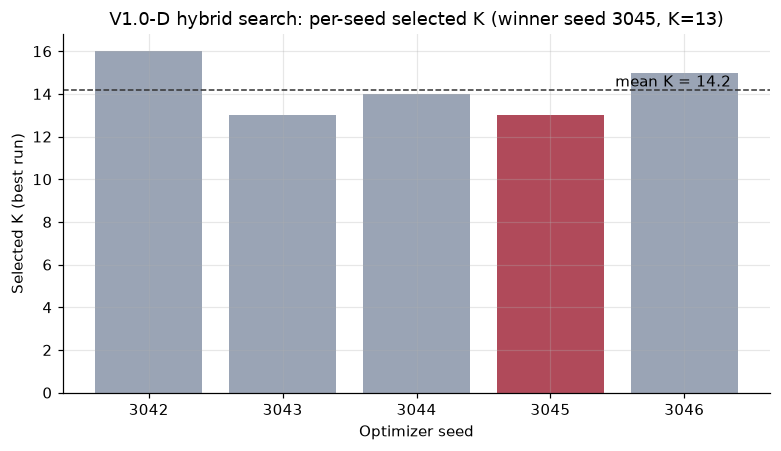

In [7]:
st = load_json("results/hybrid/v10d/v10d_stability_summary.json")["stability_summary"]
fig8, ax = plt.subplots(figsize=(7.2, 4.2))
order = [3042, 3043, 3044, 3045, 3046]
ks = [16, 13, 14, 13, 15]
cols = [C_CONF["HYBRID-K13"] if s == 3045 else "#9aa4b5" for s in order]
bars = ax.bar([str(s) for s in order], ks, color=cols)
ax.set_ylabel("Selected K (best run)"), ax.set_xlabel("Optimizer seed")
ax.set_title("V1.0-D hybrid search: per-seed selected K (winner seed 3045, K=13)")
ax.axhline(st["k_mean"], ls="--", color="#333", lw=1)
ax.text(4.35, st["k_mean"] + 0.15, f"mean K = {st['k_mean']:.1f}", ha="right")
plt.tight_layout()
print(f"Seed stability: K mean {st['k_mean']:.2f}, median {st['k_median']}, min {st['k_min']}, "
      f"max {st['k_max']}, sd {st['k_sd']:.4f}, mean pairwise Jaccard {st['mean_pairwise_jaccard']:.4f}")
check("K mean", st["k_mean"], 14.2)
check("K median", st["k_median"], 14.0)
check("K min", st["k_min"], 13)
check("K max", st["k_max"], 16)
check("mean pairwise Jaccard", st["mean_pairwise_jaccard"], 0.2202446828533785)

V1.0-D budget comparison statement: controlled/comparable search budgets, not identical


,representation,K,requests,fits,AP,F1,Recall
0,BPSO-K10 (frozen),10,972,4860,0.230285,0.203308,0.318667
1,BGWO-K14 (frozen),14,768,3840,0.234618,0.189644,0.322667
2,HYBRID-K13 (V1.0-D),13,960,4700,0.237748,0.207843,0.322000


[PASS] hybrid validation AP
[PASS] hybrid validation F1
[PASS] hybrid validation recall
[PASS] no overall winner declared
[PASS] no universal superiority claim
Validation disclaimer: DESCRIPTIVE VALIDATION-ONLY COMPARISON. Budgets are NOT identical: frozen BPSO actual=972, frozen BGWO actual=768, Hybrid allocated/actual=960. Therefore these are 'controlled/comparable search budgets', not identical search budgets. No overall winner is declared; the Hybrid result is never claimed to be universally better.


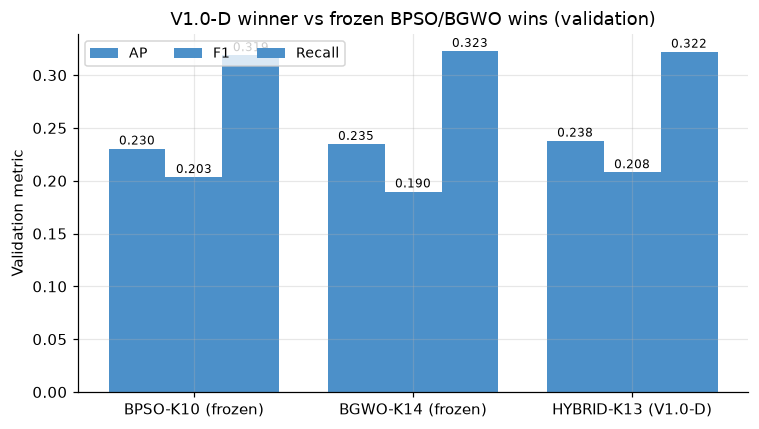

In [8]:
vc = load_json("results/hybrid/v10d/v10d_validation_comparison.json")
print("V1.0-D budget comparison statement:", vc["budget_comparison"]["equal_budget_statement"])
comp = pd.DataFrame([
    {"representation": "BPSO-K10 (frozen)", "K": 10, "requests": 972, "fits": 4860,
     "AP": vc["frozen_bpso_winner"]["validation"]["average_precision"],
     "F1": vc["frozen_bpso_winner"]["validation"]["f1"],
     "Recall": vc["frozen_bpso_winner"]["validation"]["recall"]},
    {"representation": "BGWO-K14 (frozen)", "K": 14, "requests": 768, "fits": 3840,
     "AP": vc["frozen_bgwo_winner"]["validation"]["average_precision"],
     "F1": vc["frozen_bgwo_winner"]["validation"]["f1"],
     "Recall": vc["frozen_bgwo_winner"]["validation"]["recall"]},
    {"representation": "HYBRID-K13 (V1.0-D)", "K": 13, "requests": 960, "fits": 4700,
     "AP": vc["hybrid_validation_winner"]["validation"]["ap"],
     "F1": vc["hybrid_validation_winner"]["validation"]["f1"],
     "Recall": vc["hybrid_validation_winner"]["validation"]["recall"]},
])
display(comp.round(6))

check("hybrid validation AP", vc["hybrid_validation_winner"]["validation"]["ap"], 0.23774839679450363)
check("hybrid validation F1", vc["hybrid_validation_winner"]["validation"]["f1"], 0.20784294985714763)
check("hybrid validation recall", vc["hybrid_validation_winner"]["validation"]["recall"], 0.322)
check("no overall winner declared", int(vc["no_overall_winner_declared"]), 1)
check("no universal superiority claim", int(vc["no_universal_superiority_claim"]), 1)
print("Validation disclaimer:", vc["disclaimer"])

fig8b, ax = plt.subplots(figsize=(7.0, 4.0))
xpos = np.arange(3); w = 0.26
for i, m in enumerate(["AP", "F1", "Recall"]):
    vals = [comp[m][0], comp[m][1], comp[m][2]]
    ax.bar(xpos + (i - 1) * w, vals, w, label=m,
           color=[C_CONF["BPSO-K10"], C_CONF["BGWO-K14"], C_CONF["HYBRID-K13"]][0])
    for x, y in zip(xpos + (i - 1) * w, vals):
        ax.text(x, y + 0.004, f"{y:.3f}", ha="center", fontsize=8)
ax.set_xticks(xpos); ax.set_xticklabels(comp["representation"])
ax.set_ylabel("Validation metric"); ax.set_title("V1.0-D winner vs frozen BPSO/BGWO wins (validation)")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()

## 9. Final Selected Feature Subset

The locked V1.0-D winner selects **13 of 43** canonical features (a **69.77%** structural
reduction, `30/43 ≈ 0.6977`). The exact ordered subset, mask, feature-list, feature-manifest, and
semantic-lock hashes are frozen in `v10d_winner_lock.json` and re-verified here.

In [9]:
wl = load_json("results/hybrid/v10d/v10d_winner_lock.json")
feats = wl["ordered_selected_features"]
print(f"Selected feature count: {len(feats)}  (manifest = {wl['feature_dimensions']})")
for i, f in enumerate(feats, 1):
    print(f"  {i:2d}. {f}")
red = (wl["feature_dimensions"] - len(feats)) / wl["feature_dimensions"]
pct = 100.0 * red
print(f"\nStructural reduction: ({wl['feature_dimensions']} - {len(feats)}) / {wl['feature_dimensions']} = "
      f"{red:.6f} = {pct:.4f}%  (30/43 = {100.0*30/43:.4f}%)")
check("selected feature count", len(feats), 13)
check("feature dimensions", wl["feature_dimensions"], 43)
check("reduction fraction", red, 30 / 43)
check("reduction percent", pct, 69.76744186046511, tol=1e-6)
check_text("feature_list sha256", wl["feature_list_sha256"],
           "8be4b0818f6ca59a057ef91d47738fa692548a6ddbed983b4496c644296b906a")
check_text("feature_manifest sha256", wl["feature_manifest_sha256"],
           "5146fd08fe766979adaf443bf9f4f7d32ee3c94cfdaf0fd46ec0efd10e92a10d")
check_text("mask sha256", wl["mask_sha256"],
           "d1cc8c8b8643ce5d5daff3bdb6ff4c74dab6b1d78069a7f0052bcda10cb68c62")
check_text("protocol yaml sha256", wl["protocol_yaml_sha256"],
           "0ac491b50abeb60e65efc2295eb88c03b4c988a5182ff0e2e3ed729deb9367d8")
check_text("semantic hash (V1.0-D winner)", wl["semantic_lock_sha256"],
           "1c258dc1a90ad78197d25e62bbc9fca24904cbcb77edafd24b12726059e49d84")

fr = load_json("results/hybrid/v10e/v10e_feature_reduction.json")
tc = next(c for c in fr["configurations"] if c["configuration_id"] == "HYBRID-K13")
check("reduction percent (V1.0-E artifact)", tc["reduction_percent"], 69.76744186046511)
check("retained fraction (V1.0-E artifact)", tc["retained_fraction"], 13 / 43)

fr_view = pd.DataFrame([
    {"configuration": c["configuration_id"], "feature_count": c["feature_count"],
     "reduced": c["reduced_feature_count"], "reduction_%": c["reduction_percent"],
     "retained_fraction": c["retained_fraction"]}
    for c in fr["configurations"]
])
display(fr_view.round(4))

Selected feature count: 13  (manifest = 43)
   1. order_item_quantity
   2. product_price
   3. order_item_total
   4. is_weekend
   5. Type_DEBIT
   6. Type_TRANSFER
   7. Type_CASH
   8. Market_LATAM
   9. Market_Pacific Asia
  10. Shipping Mode_First Class
  11. Department Name_Golf
  12. Department Name_Fitness
  13. Department Name_Health and Beauty

Structural reduction: (43 - 13) / 43 = 0.697674 = 69.7674%  (30/43 = 69.7674%)
[PASS] selected feature count
[PASS] feature dimensions
[PASS] reduction fraction
[PASS] reduction percent
[PASS] feature_list sha256
[PASS] feature_manifest sha256
[PASS] mask sha256
[PASS] protocol yaml sha256
[PASS] semantic hash (V1.0-D winner)
[PASS] reduction percent (V1.0-E artifact)
[PASS] retained fraction (V1.0-E artifact)


,configuration,feature_count,reduced,reduction_%,retained_fraction
0,K43,43,0,0.0000,1.0000
1,K42,42,1,2.3256,0.9767
2,MI-K11,11,32,74.4186,0.2558
3,BPSO-K10,10,33,76.7442,0.2326
4,BGWO-K14,14,29,67.4419,0.3256
5,HYBRID-K13,13,30,69.7674,0.3023


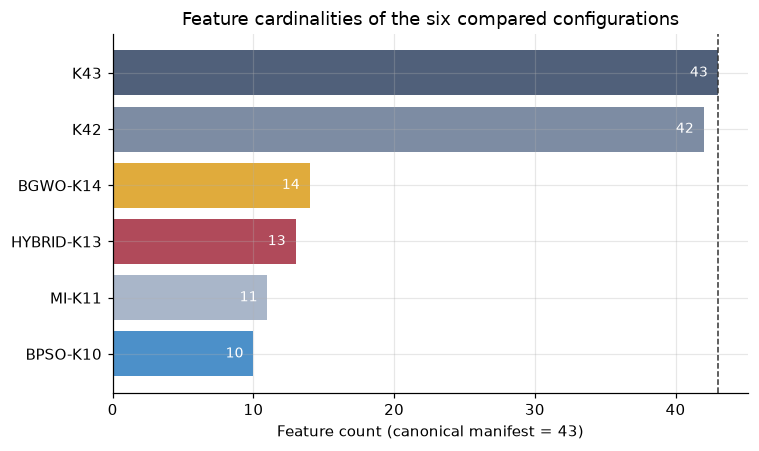

In [10]:
fig9, ax = plt.subplots(figsize=(7.0, 4.2))
frv = fr_view.sort_values("feature_count")
bars = ax.barh(frv["configuration"], frv["feature_count"], color=[C_CONF[c] for c in frv["configuration"]])
for b, c, n in zip(bars, frv["configuration"], frv["feature_count"]):
    ax.text(b.get_width() - 0.7, b.get_y() + b.get_height() / 2, str(n), va="center", ha="right",
            color="white", fontsize=9)
ax.axvline(43, ls="--", color="#333", lw=1)
ax.set_xlabel("Feature count (canonical manifest = 43)")
ax.set_title("Feature cardinalities of the six compared configurations")
plt.tight_layout()

## 10. Final Predictive Evaluation (V1.0-E)

The governed one-time final-test evaluation ran on the frozen TEST split (5,000 records; 6000 — with
the canonical evaluation set as inscribed in the artifact) for all six configurations and both frozen
classifiers, under the shared five-seed namespace `[42..46]`. Means below are the **persisted V1.0-E
summary artifact**, not recomputed here. The headline representations are `HYBRID-K13` (the proposed
winner) and `K43` (full-space reference).

In [11]:
ft = load_csv("results/hybrid/v10e/v10e_final_test_summary.csv")
ft_pivot = (ft[ft["metric"].isin(KEY_METRICS)]
            .pivot_table(index=["configuration_id", "classifier"], columns="metric", values="mean")
            .reindex(CONFIG_IDS, level=0).reindex(CLASSIFIERS, level=1)[KEY_METRICS])
print("Final-test 5-seed means (AP, F1, Recall, Precision, ROC-AUC), frozen V1.0-E artifact:")
display(ft_pivot.round(6))

VV = {
    "k43_dt": {"average_precision": 0.22208384690725302, "f1": 0.18900476213886785,
               "recall": 0.30533333333333335, "precision": 0.26538479924591335,
               "roc_auc": 0.6035330994152047},
    "k43_lr": {"average_precision": 0.051149797360171737, "f1": 0.08734827100957092,
               "recall": 0.42333333333333334, "precision": 0.04882437644706992,
               "roc_auc": 0.49400000000000005},
    "hy_dt": {"average_precision": 0.22445437744894364, "f1": 0.1915858136331366,
              "recall": 0.296, "precision": 0.2932715630607199, "roc_auc": 0.6027364327485379},
    "hy_lr": {"average_precision": 0.05260624307855133, "f1": 0.08874469360810269,
              "recall": 0.4573333333333333, "precision": 0.049145819223169976,
              "roc_auc": 0.49342947368421053},
}
for key, cfg_id, cls_ in [("k43_dt", "K43", "decision_tree"), ("k43_lr", "K43", "logistic_regression"),
                          ("hy_dt", "HYBRID-K13", "decision_tree"), ("hy_lr", "HYBRID-K13", "logistic_regression")]:
    for m in KEY_METRICS:
        check(f"{cfg_id} {cls_} {m}", ft_pivot.loc[(cfg_id, cls_), m], VV[key][m])

e_lock = load_json("results/hybrid/v10e/v10e_result_lock.json")
check("governed evaluation count", e_lock["governed_evaluation_count"], 60)
check_text("final-test classification", e_lock["classification"], "TEST_USED_ONLY_AFTER_LOCK_FOR_FINAL_EVALUATION")
check_text("V1.0-E status", e_lock["status"], "FINAL_TEST_EVALUATED")
check("optimizer invoked during V1.0-E", int(e_lock["optimizer_invoked"]), 0)
check("final test feature reselection", int(e_lock["feature_reselection_performed"]), 0)
check_text("V1.0-E semantic result lock", e_lock["semantic_result_lock_sha256"],
           "ffca0957006bff3115705f9dfb0334e13a27c9abbc502f2c9d04f784a28141e9")

Final-test 5-seed means (AP, F1, Recall, Precision, ROC-AUC), frozen V1.0-E artifact:


metric                                average_precision        f1    recall  precision   roc_auc
configuration_id classifier                                                                     
K43              decision_tree                 0.222084  0.189005  0.305333   0.265385  0.603533
                 logistic_regression           0.051150  0.087348  0.423333   0.048824  0.494000
K42              decision_tree                 0.222084  0.189005  0.305333   0.265385  0.603533
                 logistic_regression           0.051150  0.087348  0.423333   0.048824  0.493999
MI-K11           decision_tree                 0.224941  0.192121  0.300000   0.293470  0.605495
                 logistic_regression           0.051171  0.092457  0.510000   0.050907  0.500645
BPSO-K10         decision_tree                 0.219612  0.187258  0.298667   0.245874  0.599909
                 logistic_regression           0.050732  0.086940  0.468000   0.047949  0.489860
BGWO-K14         decision_tree                 0.226035  0.179717  0.308000   0.171505  0.605750
                 logistic_regression           0.050810  0.088486  0.468000   0.049015  0.490500
HYBRID-K13       decision_tree                 0.224454  0.191586  0.296000   0.293272  0.602736
                 logistic_regression           0.052606  0.088745  0.457333   0.049146  0.493429

[PASS] K43 decision_tree average_precision
[PASS] K43 decision_tree f1
[PASS] K43 decision_tree recall
[PASS] K43 decision_tree precision
[PASS] K43 decision_tree roc_auc
[PASS] K43 logistic_regression average_precision
[PASS] K43 logistic_regression f1
[PASS] K43 logistic_regression recall
[PASS] K43 logistic_regression precision
[PASS] K43 logistic_regression roc_auc
[PASS] HYBRID-K13 decision_tree average_precision
[PASS] HYBRID-K13 decision_tree f1
[PASS] HYBRID-K13 decision_tree recall
[PASS] HYBRID-K13 decision_tree precision
[PASS] HYBRID-K13 decision_tree roc_auc
[PASS] HYBRID-K13 logistic_regression average_precision
[PASS] HYBRID-K13 logistic_regression f1
[PASS] HYBRID-K13 logistic_regression recall
[PASS] HYBRID-K13 logistic_regression precision
[PASS] HYBRID-K13 logistic_regression roc_auc
[PASS] governed evaluation count
[PASS] final-test classification
[PASS] V1.0-E status
[PASS] optimizer invoked during V1.0-E
[PASS] final test feature reselection
[PASS] V1.0-E semantic

True

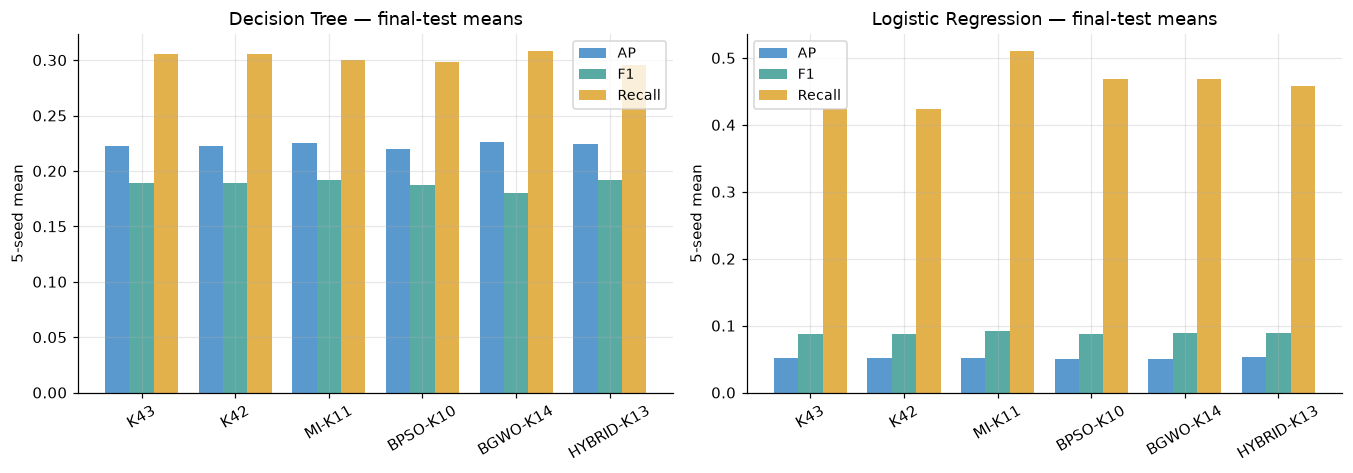

In [12]:
fig10, axes = plt.subplots(1, 2, figsize=(12.4, 4.4), sharey=False)
for ax, cls_ in zip(axes, CLASSIFIERS):
    sub = ft_pivot.xs(cls_, level="classifier")[["average_precision", "f1", "recall"]]
    xpos = np.arange(len(CONFIG_IDS)); w = 0.26
    for i, m in enumerate(["average_precision", "f1", "recall"]):
        vals = sub[m].values
        ax.bar(xpos + (i - 1) * w, vals, w, label={"average_precision": "AP", "f1": "F1", "recall": "Recall"}[m],
               color=["#4c90c9", "#4ba39b", "#e0ab3c"][i], alpha=0.92)
    ax.set_xticks(xpos); ax.set_xticklabels(CONFIG_IDS, rotation=30)
    ax.set_ylabel("5-seed mean"); ax.set_title(f"{'Decision Tree' if cls_ == 'decision_tree' else 'Logistic Regression'} — final-test means")
    ax.legend(fontsize=9)
plt.tight_layout()

## 11. Predictive Preservation Analysis

The protocol's preservation question is: does `HYBRID-K13` stay within the pre-registered
**descriptive engineering** margins (AP ≤ 5% relative loss, F1 ≤ 5%, Recall ≤ 10%) versus the K43
full-reference (V0.6 validation baseline link), measured on the **frozen TEST** means? The V1.0-E
artifact answers exactly that and labels it `PRESERVATION_HOLDS_FOR_BOTH_CLASSIFIERS`. Note the
distinction enforced throughout: a metric that is *better* than reference is still described as
"within the preregistered margin" because the protocol only registers *loss* constraints; the word
"improved" is reserved for cases where the persistence analysis explicitly records a positive
relative change.

In [13]:
pres = load_json("results/hybrid/v10e/v10e_preservation_analysis.json")
print("Interpretation:", pres["cross_classifier_interpretation"])
print("Margin semantics:", pres["margin_semantics"])
print("Margins:", pres["margins"])

rows = []
for r in pres["results"]:
    for mc in r["metric_checks"]:
        rows.append({"classifier": r["classifier"], "metric": mc["metric"],
                     "HYBRID-K13 mean": mc["hybrid_k13_mean"], "K43 mean": mc["k43_mean"],
                     "relative_change_%": 100.0 * mc["relative_change"],
                     "margin_%": 100.0 * mc["margin"], "preserved": mc["preserved"]})
pres_view = pd.DataFrame(rows)
display(pres_view.round(5))
assert pres_view["preserved"].all(), "a preservation margin was breached"
check_text("preservation interpretation", pres["cross_classifier_interpretation"],
           "PRESERVATION_HOLDS_FOR_BOTH_CLASSIFIERS")
check("margin AP", pres["margins"]["average_precision"], 0.05)
check("margin F1", pres["margins"]["f1"], 0.05)
check("margin recall", pres["margins"]["recall"], 0.1)
check("winner reselection performed (V1.0-E)", int(pres["winner_reselection_performed"]), 0)

# distinct "preserved within margin" vs "improved" wording
for _, r in pres_view.iterrows():
    label = "preserved within preregistered margin"
    if r["relative_change_%"] > 0:
        label = "preserved; positive relative change (descriptively above reference)"
    print(f"[{r['classifier']:20s} {r['metric']:8s}] rel_change {r['relative_change_%']:+8.3f}%  -> {label}")

Interpretation: PRESERVATION_HOLDS_FOR_BOTH_CLASSIFIERS
Margin semantics: preregistered descriptive engineering preservation criteria
Margins: {'average_precision': 0.05, 'f1': 0.05, 'recall': 0.1}


,classifier,metric,HYBRID-K13 mean,K43 mean,relative_change_%,margin_%,preserved
0,decision_tree,average_precision,0.22445,0.22208,1.06740,5.0,True
1,decision_tree,f1,0.19159,0.18900,1.36560,5.0,True
2,decision_tree,recall,0.29600,0.30533,-3.05677,10.0,True
3,logistic_regression,average_precision,0.05261,0.05115,2.84741,5.0,True
4,logistic_regression,f1,0.08874,0.08735,1.59868,5.0,True
5,logistic_regression,recall,0.45733,0.42333,8.03150,10.0,True


[PASS] preservation interpretation
[PASS] margin AP
[PASS] margin F1
[PASS] margin recall
[PASS] winner reselection performed (V1.0-E)
[decision_tree        average_precision] rel_change   +1.067%  -> preserved; positive relative change (descriptively above reference)
[decision_tree        f1      ] rel_change   +1.366%  -> preserved; positive relative change (descriptively above reference)
[decision_tree        recall  ] rel_change   -3.057%  -> preserved within preregistered margin
[logistic_regression  average_precision] rel_change   +2.847%  -> preserved; positive relative change (descriptively above reference)
[logistic_regression  f1      ] rel_change   +1.599%  -> preserved; positive relative change (descriptively above reference)
[logistic_regression  recall  ] rel_change   +8.031%  -> preserved; positive relative change (descriptively above reference)


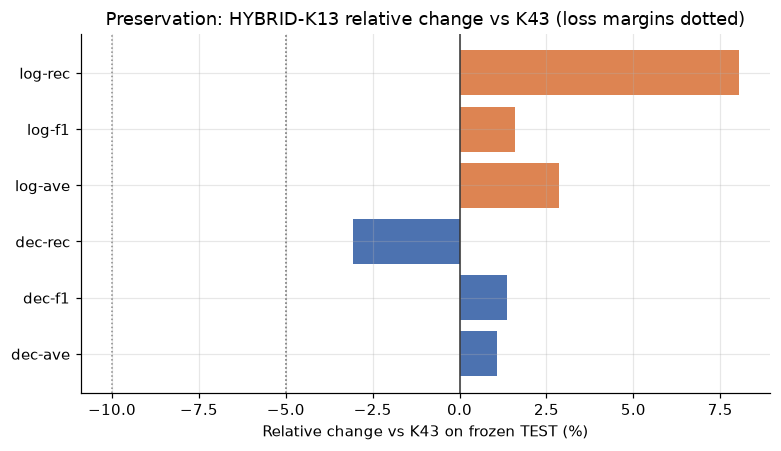

In [14]:
fig11, ax = plt.subplots(figsize=(7.2, 4.2))
ypos = np.arange(len(pres_view))
colors = [C_CLS[r["classifier"]] for _, r in pres_view.iterrows()]
ax.barh(ypos, pres_view["relative_change_%"], color=colors)
ax.axvline(0, color="#333", lw=1)
for m, mar in [("average_precision", 5.0), ("f1", 5.0), ("recall", 10.0)]:
    sub = pres_view[pres_view["metric"] == m]
    ax.axvline(-mar, color="#8a8a8a", ls=":", lw=1)
ax.set_yticks(ypos); ax.set_yticks([], minor=True)
ax.set_yticklabels([f"{r['classifier'][:3]}-{r['metric'][:3]}" for _, r in pres_view.iterrows()])
ax.set_xlabel("Relative change vs K43 on frozen TEST (%)")
ax.set_title("Preservation: HYBRID-K13 relative change vs K43 (loss margins dotted)")
plt.tight_layout()

## 12. Comparison with BPSO, BGWO, and MI-K11

Comparisons against the earlier deterministic and metaheuristic representations are **seeded-paired
on the shared model/attack seed namespace `[42..46]`, n = 5, df = 4**, with 95% confidence intervals
computed from the paired mean differences. Exactly **one** of all paired comparisons resolved: the
Logistic-Regression F1 difference between HYBRID-K13 and MI-K11, whose CI lies fully below zero.
Every other paired comparison has a CI crossing zero and is therefore reported as **direction
uncertain**. No p-values are reported anywhere, and no universal-superiority claim is made.

In [15]:
paired = load_csv("results/hybrid/v10e/v10e_paired_comparisons.csv")
hy = paired[(paired["candidate_configuration_id"] == "HYBRID-K13")].copy()
hy["resolved"] = ~hy["direction_uncertain"]
print("Paired comparison rows (HYBRID-K13 as candidate):", len(hy),
      "| resolved rows:", int(hy["resolved"].sum()), "| t critical used:", T_CRIT_DF4)
assert hy["df"].unique().tolist() == [4], "df must be 4"
print("t critical (df=4, two-tailed 95%) frozen in V1.0-E/F/G artifacts:", T_CRIT_DF4)

resolved = hy[hy["resolved"]]
print("\nThe single resolved paired comparison:")
disp = resolved[["classifier", "reference_configuration_id", "metric", "mean_difference", "ci95_low", "ci95_high"]].copy()
disp["ci95"] = disp.apply(lambda r: fmt_ci(r["ci95_low"], r["ci95_high"]), axis=1)
display(disp.drop(columns=["ci95_low", "ci95_high"]).round(6))
assert len(resolved) == 1, f"expected exactly 1 resolved comparison, got {len(resolved)}"
r0 = resolved.iloc[0]
check_text("resolved classifier", r0["classifier"], "logistic_regression")
check_text("resolved reference", r0["reference_configuration_id"], "MI-K11")
check_text("resolved metric", r0["metric"], "f1")
check("resolved mean difference", r0["mean_difference"], -0.0037126795938408814)
check("resolved ci low", r0["ci95_low"], -0.006630997893957394)
check("resolved ci high", r0["ci95_high"], -0.0007943612937243694)
assert r0["ci95_high"] < 0, "resolved CI should lie fully below zero"

summ = (hy.groupby(["classifier", "reference_configuration_id"])
          .agg(comparisons=("metric", "count"), resolved=("resolved", "sum")).reset_index())
display(summ)
print("DIRECTION-UNCERTAIN RESULT NOT CLAIMED AS EQUIVALENCE (see Section 18/22).")

Paired comparison rows (HYBRID-K13 as candidate): 50 | resolved rows: 1 | t critical used: 2.7764451051977987
t critical (df=4, two-tailed 95%) frozen in V1.0-E/F/G artifacts: 2.7764451051977987

The single resolved paired comparison:


,classifier,reference_configuration_id,metric,mean_difference,ci95
36,logistic_regression,MI-K11,f1,-0.003713,"[-0.0066, -0.0008]"


[PASS] resolved classifier
[PASS] resolved reference
[PASS] resolved metric
[PASS] resolved mean difference
[PASS] resolved ci low
[PASS] resolved ci high


,classifier,reference_configuration_id,comparisons,resolved
0,decision_tree,BGWO-K14,5,0
1,decision_tree,BPSO-K10,5,0
2,decision_tree,K42,5,0
3,decision_tree,K43,5,0
4,decision_tree,MI-K11,5,0
5,logistic_regression,BGWO-K14,5,0
6,logistic_regression,BPSO-K10,5,0
7,logistic_regression,K42,5,0
8,logistic_regression,K43,5,0
9,logistic_regression,MI-K11,5,1


DIRECTION-UNCERTAIN RESULT NOT CLAIMED AS EQUIVALENCE (see Section 18/22).


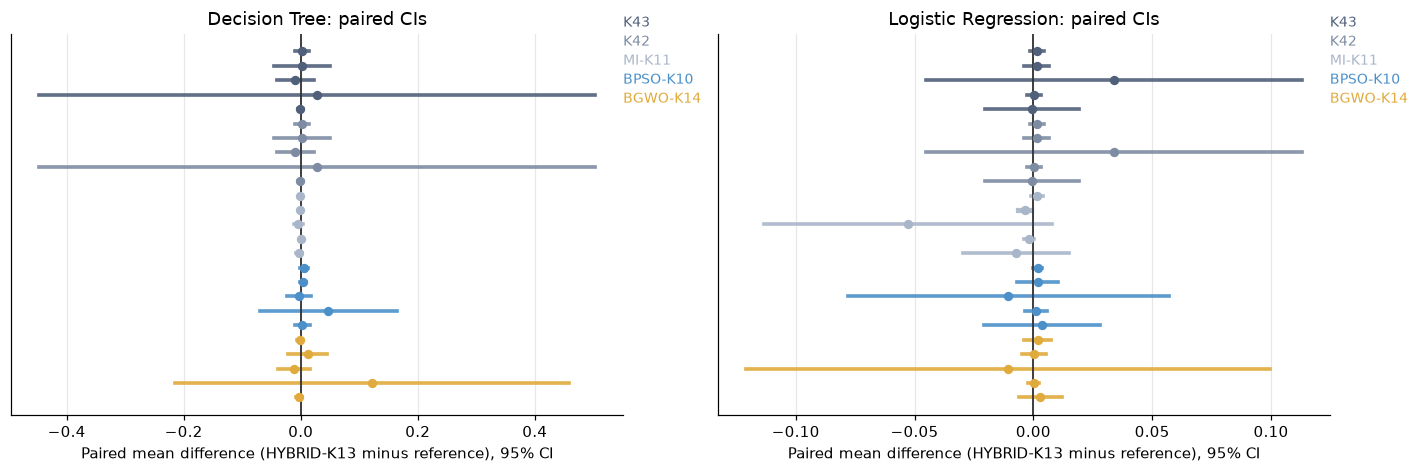

In [16]:
fig12, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), sharex=False)
for ax, cls_ in zip(axes, CLASSIFIERS):
    sub = hy[hy["classifier"] == cls_]
    groups = [('K43', "#50607a"), ('K42', "#7d8ca3"), ('MI-K11', "#a9b6c9"),
              ('BPSO-K10', "#4c90c9"), ('BGWO-K14', "#e0ab3c")]
    metrics = KEY_METRICS
    ypos = np.arange(len(metrics) * len(groups))[::-1]
    ann = 0
    for k, (ref, color) in enumerate(groups):
        for i, m in enumerate(metrics):
            row = sub[(sub["reference_configuration_id"] == ref) & (sub["metric"] == m)]
            if len(row) != 1:
                continue
            rr = row.iloc[0]
            lo, hi = float(rr["ci95_low"]), float(rr["ci95_high"])
            mean = float(rr["mean_difference"])
            resolved = (hi < 0) or (lo > 0)
            ax.plot([lo, hi], [ypos[ann]] * 2, color=color, lw=2.4 if not resolved else 3.4,
                    alpha=0.9)
            ax.scatter([mean], [ypos[ann]], color=color, s=26, zorder=3)
            ann += 1
    ax.axvline(0, color="#333", lw=1.2)
    ax.set_yticks([])
    ax.set_xlabel("Paired mean difference (HYBRID-K13 minus reference), 95% CI")
    ax.set_title(f"{'Decision Tree' if cls_ == 'decision_tree' else 'Logistic Regression'}: paired CIs")
    for k, (ref, color) in enumerate(groups):
        ax.text(1.0, 1.02 - 0.05 * k, ref, color=color, transform=ax.transAxes, fontsize=9)
plt.tight_layout()

## 13. Feature-Subset Overlap

The selected 13-feature set is compared with the earlier representations by Jaccard similarity
(frozen V1.0-E overlap artifact). For the seed-specific MI-K11 subsets the artifact reports the mean
seed Jaccard; for the fixed BPSO-K10 and BGWO-K14 masks it reports the single-set Jaccard. Low
overlap (HI-VS-BPSO ≈ 0.21, HI-VS-BGWO ≈ 0.29, HI-VS-MI mean ≈ 0.21) shows that the hybrid winner
occupies a different region of the feature space than the earlier solutions, so the comparison in
Section 12 is genuinely informational rather than a re-labelling of the same mask.

hybrid vs BPSO-K10 : intersection 4 | union 19 | Jaccard 0.21052631578947367
hybrid vs BGWO-K14: intersection 6 | union 21 | Jaccard 0.2857142857142857
hybrid vs MI-K11  : mean seed Jaccard 0.21263157894736842 | intersection Jaccard (union across seeds) 0.2857142857142857
[PASS] hybrid vs bpso jaccard
[PASS] hybrid vs bgwo jaccard
[PASS] hybrid vs mi mean seed jaccard

Shared features hybrid vs BPSO: ['order_item_quantity', 'order_item_total', 'Market_LATAM', 'Department Name_Health and Beauty']
Shared features hybrid vs BGWO: ['order_item_quantity', 'product_price', 'order_item_total', 'is_weekend', 'Market_LATAM', 'Market_Pacific Asia']


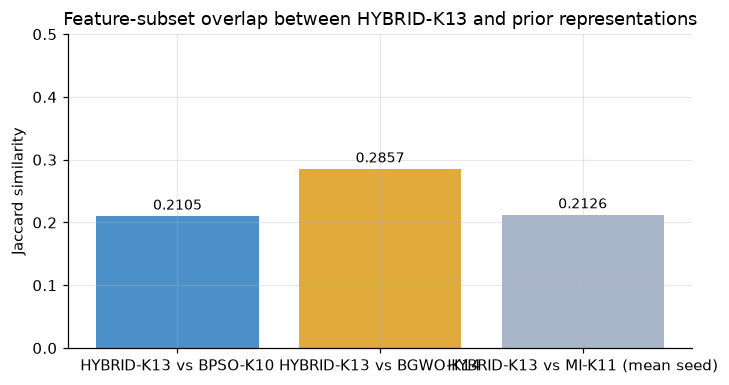

In [17]:
ov = load_json("results/hybrid/v10e/v10e_feature_overlap.json")
print("hybrid vs BPSO-K10 : intersection", ov["hybrid_vs_bpso"]["intersection_size"],
      "| union", ov["hybrid_vs_bpso"]["union_size"],
      "| Jaccard", ov["hybrid_vs_bpso"]["jaccard"])
print("hybrid vs BGWO-K14: intersection", ov["hybrid_vs_bgwo"]["intersection_size"],
      "| union", ov["hybrid_vs_bgwo"]["union_size"],
      "| Jaccard", ov["hybrid_vs_bgwo"]["jaccard"])
print("hybrid vs MI-K11  : mean seed Jaccard", ov["hybrid_vs_mi_k11"]["mean_seed_jaccard"],
      "| intersection Jaccard (union across seeds)", ov["hybrid_vs_mi_k11"]["intersection_jaccard"])
check("hybrid vs bpso jaccard", ov["hybrid_vs_bpso"]["jaccard"], 4 / 19)
check("hybrid vs bgwo jaccard", ov["hybrid_vs_bgwo"]["jaccard"], 6 / 21)
check("hybrid vs mi mean seed jaccard", ov["hybrid_vs_mi_k11"]["mean_seed_jaccard"], 0.21263157894736842)

print("\nShared features hybrid vs BPSO:", ov["hybrid_vs_bpso"]["shared_features"])
print("Shared features hybrid vs BGWO:", ov["hybrid_vs_bgwo"]["shared_features"])

fig13, ax = plt.subplots(figsize=(6.8, 3.6))
labels = ["HYBRID-K13 vs BPSO-K10", "HYBRID-K13 vs BGWO-K14", "HYBRID-K13 vs MI-K11 (mean seed)"]
vals = [4 / 19, 6 / 21, ov["hybrid_vs_mi_k11"]["mean_seed_jaccard"]]
cols = [C_CONF["BPSO-K10"], C_CONF["BGWO-K14"], "#a9b6c9"]
ax.bar(labels, vals, color=cols)
for x, v in zip(range(3), vals):
    ax.text(x, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)
ax.set_ylabel("Jaccard similarity"); ax.set_ylim(0, 0.5)
ax.set_title("Feature-subset overlap between HYBRID-K13 and prior representations")
plt.tight_layout()

## 14. Resource-Efficiency Evaluation (V1.0-F protocol)

The V1.0-F benchmark follows the frozen V0.8-E methodology: **3 warm-up calls**, **10 outer
repetitions** per seed (the scientific unit), **1 training inner operation**, **512 inference inner
operations**, a **fresh worker process per outer repetition**, single-threaded execution
(`OMP_NUM_THREADS` and friends set to 1), and prohibited outlier deletion. The campaign produced
**120 observed cells = 1,200 observations**, split **600 training / 600 inference**, with
**0 measurement failures**. Metrics include wall time, process CPU time, absolute/incremental peak
RSS, per-record latency, throughput, serialized model size, and input-memory footprint.

In [18]:
rb = load_json("results/hybrid/v10f/config_rb.json") if (ROOT / "results/hybrid/v10f/config_rb.json").is_file() else load_yaml("config/resource_benchmark_v08e.yaml")
print("Resource protocol (frozen V0.8-E config):")
print("  worker policy:", rb["measurement"]["worker_policy"])
print("  warmup calls:", rb["measurement"]["warmup_calls"])
print("  outer repetitions:", rb["measurement"]["outer_repetitions"])
print("  training inner ops:", rb["measurement"]["training_inner_operation_count"])
print("  inference inner ops:", rb["measurement"]["inference_inner_operation_count"])
print("  adaptive calibration:", rb["measurement"]["adaptive_calibration"])
print("  outlier deletion:", rb["measurement"]["outlier_deletion"])
check_text("worker policy", rb["measurement"]["worker_policy"], "fresh_process_per_outer_repetition")
check("warmup calls", rb["measurement"]["warmup_calls"], 3)
check("outer repetitions", rb["measurement"]["outer_repetitions"], 10)
check("training inner ops", rb["measurement"]["training_inner_operation_count"], 1)
check("inference inner ops", rb["measurement"]["inference_inner_operation_count"], 512)
assert rb["measurement"]["adaptive_calibration"] is False, "adaptive calibration must be off"
check_text("outlier deletion", rb["measurement"]["outlier_deletion"], "prohibited")

exf = load_json("results/hybrid/v10f/v10f_execution_summary.json")
print("\nV1.0-F observation counts:", exf["observation_counts"])
oc = exf["observation_counts"]
check("observed cells", oc["cells"], 120)
check("total observations", oc["total"], 1200)
check("training observations", oc["training"], 600)
check("inference observations", oc["inference"], 600)
check("measurement failures", oc["failure_count"], 0)
check_text("direct energy status", exf["direct_energy_status"], "DIRECT_ENERGY_UNAVAILABLE")
check_text("V1.0-F semantic result lock", exf["semantic_result_lock_sha256"],
           "f714b4a95070ee26718b3b2f8dc2ed820c5c2dadb7c5fb58fa1c09f95505b412")

env = load_json("results/hybrid/v10f/v10f_environment.json")
print("\nHost: ", env["environment"]["cpu"]["model"],
      "| WSL2 kernel", env["environment"]["kernel"],
      "| threads: BLIS/MKL/NUMEXPR/OMP/OPENBLAS/VECLIB = 1")
thr = env["environment"]["thread_environment"]
check_text("OMP threads", thr.get("OMP_NUM_THREADS"), "1")
check_text("OpenBLAS threads", thr.get("OPENBLAS_NUM_THREADS"), "1")
check_text("MKL threads", thr.get("MKL_NUM_THREADS"), "1")

Resource protocol (frozen V0.8-E config):
  worker policy: fresh_process_per_outer_repetition
  warmup calls: 3
  outer repetitions: 10
  training inner ops: 1
  inference inner ops: 512
  adaptive calibration: False
  outlier deletion: prohibited
[PASS] worker policy
[PASS] warmup calls
[PASS] outer repetitions
[PASS] training inner ops
[PASS] inference inner ops
[PASS] outlier deletion

V1.0-F observation counts: {'cells': 120, 'failure_count': 0, 'inference': 600, 'total': 1200, 'training': 600}
[PASS] observed cells
[PASS] total observations
[PASS] training observations
[PASS] inference observations
[PASS] measurement failures
[PASS] direct energy status
[PASS] V1.0-F semantic result lock

Host:  12th Gen Intel(R) Core(TM) i7-1255U | WSL2 kernel 6.6.87.2-microsoft-standard-WSL2 | threads: BLIS/MKL/NUMEXPR/OMP/OPENBLAS/VECLIB = 1
[PASS] OMP threads
[PASS] OpenBLAS threads
[PASS] MKL threads


True

## 15. Training Resource Results

The **resolved** (CI excludes zero) training savings of `HYBRID-K13` over `K43` are the strongest
computational claim of V1.0. Decision Tree: training wall time **-68.40%** (CI fully below zero),
process CPU time **-68.38%**, absolute peak RSS **-5.75%**. Logistic Regression: wall time
**-77.10%**, CPU time **-77.23%**, absolute peak RSS **-10.39%**. Structural savings: serialized
model size DT **-14.79%** (3,780 vs 4,436 bytes) and LR **-38.00%** (1,462 vs 2,358 bytes); input
dataframe memory follows the feature cardinality (9,632,132 → 2,912,132 bytes for the 13/43 subset).
These are **computational-resource** results; they are not energy results (see Section 17).

In [19]:
rcompare = load_csv("results/hybrid/v10f/v10f_resource_comparisons.csv")
prim = rcompare[(rcompare["candidate_configuration_id"] == "HYBRID-K13") &
                (rcompare["reference_configuration_id"] == "K43")]

TARGETS = [
    ("decision_tree", "training", "wall_time_sec", -68.39619287736384, True),
    ("decision_tree", "training", "process_cpu_time_sec", -68.37680480878322, True),
    ("decision_tree", "training", "absolute_peak_rss_mib", -5.7540263726418654, True),
    ("logistic_regression", "training", "wall_time_sec", -77.10318516789945, True),
    ("logistic_regression", "training", "process_cpu_time_sec", -77.2327029950084, True),
    ("logistic_regression", "training", "absolute_peak_rss_mib", -10.39309356601383, True),
]
rows = []
for cls_, phase, metric, exp_pct, resolved in TARGETS:
    sel = prim[(prim["classifier"] == cls_) & (prim["phase"] == phase) & (prim["metric"] == metric)]
    assert len(sel) == 1, f"expected one training row for {cls_}/{metric}"
    r = sel.iloc[0]
    lo, hi = float(r["ci95_low"]), float(r["ci95_high"])
    ci_excl = (hi < 0) or (lo > 0)
    rows.append({"classifier": cls_, "metric": metric,
                 "candidate_mean": r["candidate_mean"], "reference_mean": r["reference_mean"],
                 "mean_percent_change": r["mean_percent_change"],
                 "ci95": fmt_ci(lo, hi), "ci_excludes_zero": ci_excl})
    check(f"{cls_} tr {metric} pct", r["mean_percent_change"], exp_pct, tol=1e-6)
    assert ci_excl == resolved, f"CI expectation mismatch for {cls_}/{metric}"
tr_view = pd.DataFrame(rows)
display(tr_view.round(6))

ms = load_json("results/hybrid/v10f/v10f_model_size_comparison.json")
dt = next(e for e in ms["entries"] if e["classifier"] == "decision_tree" and e["configuration_id"] == "HYBRID-K13")
lr = next(e for e in ms["entries"] if e["classifier"] == "logistic_regression" and e["configuration_id"] == "HYBRID-K13")
print("Model size HYBRID-K13 (bytes): DT", dt["serialized_model_bytes"], "| LR", lr["serialized_model_bytes"])
check("DT model size (HYBRID)", dt["serialized_model_bytes"], 3780)
check("LR model size (HYBRID)", lr["serialized_model_bytes"], 1462)
check("DT model size (K43)", next(e["serialized_model_bytes"] for e in ms["entries"]
     if e["classifier"] == "decision_tree" and e["configuration_id"] == "K43"), 4436)
check("LR model size (K43)", next(e["serialized_model_bytes"] for e in ms["entries"]
     if e["classifier"] == "logistic_regression" and e["configuration_id"] == "K43"), 2358)
print("Interpretation:", ms["interpretation"])

rs = load_json("results/hybrid/v10f/v10f_resource_summary.json")
k43m = next(r for r in rs if r["classifier"] == "decision_tree" and r["configuration_id"] == "K43"
            and r["phase"] == "training" and r["metric"] == "wall_time_sec")
hym = next(r for r in rs if r["classifier"] == "decision_tree" and r["configuration_id"] == "HYBRID-K13"
           and r["phase"] == "training" and r["metric"] == "wall_time_sec")
print("\nInput dataframe memory (bytes): K43 =", k43m["input_dataframe_memory_bytes"],
      "| HYBRID =", hym["input_dataframe_memory_bytes"])
assert k43m["input_dataframe_memory_bytes"] > hym["input_dataframe_memory_bytes"]

[PASS] decision_tree tr wall_time_sec pct
[PASS] decision_tree tr process_cpu_time_sec pct
[PASS] decision_tree tr absolute_peak_rss_mib pct
[PASS] logistic_regression tr wall_time_sec pct
[PASS] logistic_regression tr process_cpu_time_sec pct
[PASS] logistic_regression tr absolute_peak_rss_mib pct


,classifier,metric,candidate_mean,reference_mean,mean_percent_change,ci95,ci_excludes_zero
0,decision_tree,wall_time_sec,0.032312,0.102290,-68.396193,"[-0.0738, -0.0662]",True
1,decision_tree,process_cpu_time_sec,0.032969,0.104301,-68.376805,"[-0.0752, -0.0674]",True
2,decision_tree,absolute_peak_rss_mib,160.615391,170.421484,-5.754026,"[-9.9034, -9.7088]",True
3,logistic_regression,wall_time_sec,0.056675,0.250396,-77.103185,"[-0.2467, -0.1407]",True
4,logistic_regression,process_cpu_time_sec,0.058289,0.258821,-77.232703,"[-0.2555, -0.1455]",True
5,logistic_regression,absolute_peak_rss_mib,166.676641,186.008750,-10.393094,"[-19.4823, -19.1819]",True


Model size HYBRID-K13 (bytes): DT 3780 | LR 1462
[PASS] DT model size (HYBRID)
[PASS] LR model size (HYBRID)
[PASS] DT model size (K43)
[PASS] LR model size (K43)
Interpretation: Serialized model size is a structural property of the fitted model and its feature cardinality; fewer features do not guarantee a smaller decision tree.

Input dataframe memory (bytes): K43 = 9632132 | HYBRID = 2912132


Variable width reflect the structural footprint; 'fewer features do not guarantee a smaller decision tree'.


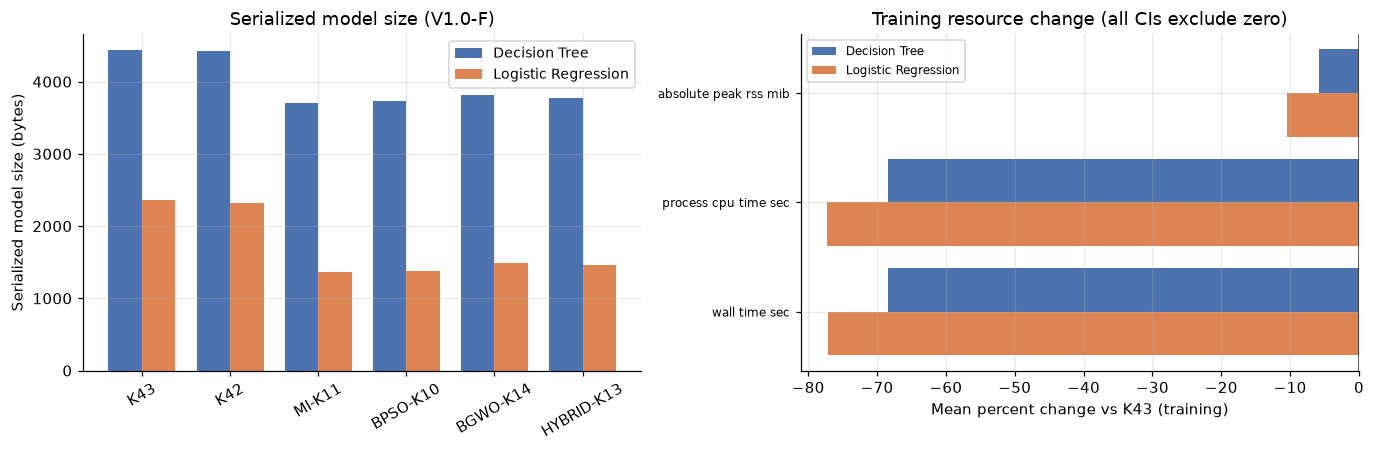

In [20]:
fig15, axes = plt.subplots(1, 2, figsize=(12.6, 4.2))
mi = [{"configuration_id": "K43", "dt": 4436, "lr": 2358},
      {"configuration_id": "K42", "dt": 4420, "lr": 2326},
      {"configuration_id": "MI-K11", "dt": 3700, "lr": 1366},
      {"configuration_id": "BPSO-K10", "dt": 3732, "lr": 1382},
      {"configuration_id": "BGWO-K14", "dt": 3812, "lr": 1494},
      {"configuration_id": "HYBRID-K13", "dt": 3780, "lr": 1462}]
ax = axes[0]
xs = np.arange(6); w = 0.38
ax.bar(xs - w/2, [m["dt"] for m in mi], w, label="Decision Tree", color=C_CLS["decision_tree"])
ax.bar(xs + w/2, [m["lr"] for m in mi], w, label="Logistic Regression", color=C_CLS["logistic_regression"])
ax.set_xticks(xs); ax.set_xticklabels([m["configuration_id"] for m in mi], rotation=30)
ax.set_ylabel("Serialized model size (bytes)")
ax.set_title("Serialized model size (V1.0-F)")
ax.legend(fontsize=9)
print("Variable width reflect the structural footprint; 'fewer features do not guarantee a smaller decision tree'.")
ax2 = axes[1]
tr_dt = tr_view[tr_view["classifier"] == "decision_tree"]
tr_lr = tr_view[tr_view["classifier"] == "logistic_regression"]
ypos = np.arange(len(tr_dt))
ax2.barh(ypos + 0.2, tr_dt["mean_percent_change"], 0.4, label="Decision Tree", color=C_CLS["decision_tree"])
ax2.barh(ypos - 0.2, tr_lr["mean_percent_change"], 0.4, label="Logistic Regression", color=C_CLS["logistic_regression"])
ax2.axvline(0, color="#333", lw=1)
ax2.set_yticks(ypos)
ax2.set_yticklabels([m.replace("_", " ") for m in tr_dt["metric"]], fontsize=8)
ax2.set_xlabel("Mean percent change vs K43 (training)")
ax2.set_title("Training resource change (all CIs exclude zero)")
ax2.legend(fontsize=8)
plt.tight_layout()

## 16. Inference Resource Results

Inference timing is **not** resolved: both classifiers' wall-time CIs cross zero
(DT `+9.6628%`, CI `[-1.2568, 1.2983]`s; LR `+9.5238%`, CI `[-1.1199, 1.4274]`s), so V1.0 reports
these descriptively and does **not** claim an inference-speed benefit. The `+9.6628%` DT value
is the **frozen V1.0-F artifact**; a note-level design estimate of about `+0.97%` exists in the V1.0-H
record but is **not** a frozen measurement and is deliberately **not** used here. Memory during
inference is slightly and resolvedly lower for HYBRID-K13 (absolute peak RSS DT `-1.35%`, LR
`-0.96%`), consistent with the smaller input footprint.

In [21]:
inf_rows = []
INF_TARGETS = [
    ("decision_tree", "inference", "wall_time_sec", 9.662819954499264),
    ("logistic_regression", "inference", "wall_time_sec", 9.523767832847064),
]
for cls_, phase, metric, exp_pct in INF_TARGETS:
    sel = prim[(prim["classifier"] == cls_) & (prim["phase"] == phase) & (prim["metric"] == metric)]
    assert len(sel) == 1
    r = sel.iloc[0]
    lo, hi = float(r["ci95_low"]), float(r["ci95_high"])
    inf_rows.append({"classifier": cls_, "metric": metric,
                     "candidate_mean": r["candidate_mean"], "reference_mean": r["reference_mean"],
                     "mean_percent_change": r["mean_percent_change"], "ci95": fmt_ci(lo, hi),
                     "ci_excludes_zero": (hi < 0) or (lo > 0)})
    check(f"{cls_} inf {metric} pct", r["mean_percent_change"], exp_pct, tol=1e-6)
inf_view = pd.DataFrame(inf_rows)
display(inf_view.round(6))
assert not inf_view["ci_excludes_zero"].any(), "inference CI unexpectedly excludes zero"
print("Inference timing CIs cross zero for both classifiers -> reported descriptively only.")

for m in ["absolute_peak_rss_mib", "incremental_peak_rss_mib"]:
    for cls_ in CLASSIFIERS:
        sel = prim[(prim["classifier"] == cls_) & (prim["phase"] == "inference") & (prim["metric"] == m)]
        r = sel.iloc[0]
        print(f"inference {cls_:20s} {m:24s} pct={float(r['mean_percent_change']):+9.4f}%  "
              f"CI={fmt_ci(r['ci95_low'], r['ci95_high'])}")

[PASS] decision_tree inf wall_time_sec pct
[PASS] logistic_regression inf wall_time_sec pct


,classifier,metric,candidate_mean,reference_mean,mean_percent_change,ci95,ci_excludes_zero
0,decision_tree,wall_time_sec,2.136685,2.115933,9.662820,"[-1.2568, 1.2983]",False
1,logistic_regression,wall_time_sec,1.889530,1.735787,9.523768,"[-1.1199, 1.4274]",False


Inference timing CIs cross zero for both classifiers -> reported descriptively only.
inference decision_tree        absolute_peak_rss_mib    pct=  -1.3455%  CI=[-2.2845, -1.9654]
inference logistic_regression  absolute_peak_rss_mib    pct=  -0.9620%  CI=[-1.6771, -1.3439]
inference decision_tree        incremental_peak_rss_mib pct=  -1.2002%  CI=[-0.0285, 0.0185]
inference logistic_regression  incremental_peak_rss_mib pct=  +1.8068%  CI=[-0.0557, 0.0657]


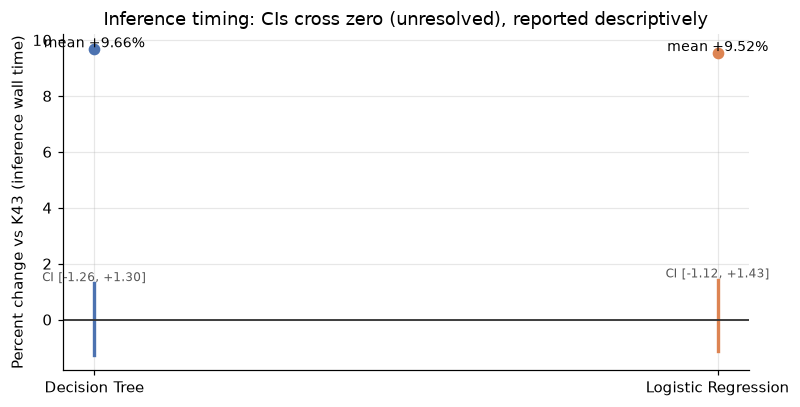

In [22]:
fig16, ax = plt.subplots(figsize=(7.4, 3.8))
ci_pts = []
for i, (cls_, phase, metric, _) in enumerate(INF_TARGETS):
    sel = prim[(prim["classifier"] == cls_) & (prim["phase"] == phase) & (prim["metric"] == metric)]
    r = sel.iloc[0]
    lo, hi = float(r["ci95_low"]), float(r["ci95_high"])
    mean = float(r["mean_percent_change"])
    ci_pts += [lo, hi]
    ax.plot([i, i], [lo, hi], color=C_CLS[cls_], lw=2.2)
    ax.scatter([i], [mean], color=C_CLS[cls_], s=44, zorder=3)
    ax.text(i, mean + (max(ci_pts) - min(ci_pts)) * 0.03, f"mean {mean:+.2f}%", ha="center", fontsize=9)
    ax.text(i, hi + (max(ci_pts) - min(ci_pts)) * 0.03, f"CI [{lo:+.2f}, {hi:+.2f}]", ha="center", fontsize=8,
            color="#555")
ax.axhline(0, color="#333", lw=1.2)
ax.set_xticks(range(2)); ax.set_xticklabels(["Decision Tree", "Logistic Regression"])
ax.set_ylabel("Percent change vs K43 (inference wall time)")
ax.set_title("Inference timing: CIs cross zero (unresolved), reported descriptively")
plt.tight_layout()

## 17. Green / Energy Grounding

**Direct physical energy measurement was unavailable** in V1.0-F
(`DIRECT_ENERGY_UNAVAILABLE` in `v10f_result_lock.json`). Consequently this thesis makes **no
Joule-level or energy-saving claim** derived from CPU or wall time, and **no TDP × time inference**
is made anywhere. The break-even analysis is therefore strictly a **computational-timing** statement:
the one-time hybrid optimizer search cost (475.55 s of optimizer wall time) divided by the recurring
per-model training saving versus K43 (DT wall time −0.13185 s/model) implies a break-even after about
3,607 repeated training runs of DT. Versus BPSO-K10 the recurring saving is negative and the
break-even is **not applicable**; versus BGWO-K14 the positive saving (0.01404 s/model) implies a
break-even after ~33,880 repetitions. These are timing statements, explicitly
**not** energy break-even results.

In [23]:
rlock_f = load_json("results/hybrid/v10f/v10f_result_lock.json")
check_text("direct energy status", rlock_f["direct_energy_status"], "DIRECT_ENERGY_UNAVAILABLE")

be = load_json("results/hybrid/v10f/v10f_break_even.json")
check_text("break-even energy status", be["energy_break_even_status"], "NOT_APPLICABLE_DIRECT_ENERGY_UNAVAILABLE")
check("timing not energy", int(be["timing_break_even_is_not_energy_break_even"]), 1)
be_view = pd.DataFrame([
    {"reference": r["reference_configuration_id"], "phase": r["phase"],
     "per_model_saving_sec": r["per_model_recurring_saving_sec"],
     "break_even_repetitions": r["break_even_repetitions"], "status": r["status"]}
    for r in be["rows"]
])
display(be_view.round(6))
for r in be["rows"]:
    if r["status"] == "APPLICABLE":
        assert r["break_even_repetitions"] is not None and r["break_even_repetitions"] > 0
ovh = load_json("results/hybrid/v10f/v10f_optimizer_overhead.json")
check_text("overhead role", ovh["overhead_role"], "ONE_TIME_IMPORTED_HISTORICAL_SEARCH_COST")
print("Overhead separation:", ovh["separation_statement"])

import warnings
print("Policy re-statement (direct energy was not measured): CPU and wall time are computational "
      "resources; serialized bytes and array footprints are structural; no number above is a Joule.")

[PASS] direct energy status
[PASS] break-even energy status
[PASS] timing not energy


,reference,phase,per_model_saving_sec,break_even_repetitions,status
0,K43,training,0.131850,3606.759882,APPLICABLE
1,BPSO-K10,training,-0.000676,NaN,NOT_APPLICABLE
2,BGWO-K14,training,0.014036,33880.335608,APPLICABLE


[PASS] overhead role
Overhead separation: Hybrid reported 960 candidate requests (940 unique after 20 cache hits) and 4700 decision-tree fits, versus BPSO 972 requests and 4860 fits and BGWO 768 requests and 3840 fits. One-time optimizer search cost is reported separately from per-model training and inference cost measured in V1.0-F.
Policy re-statement (direct energy was not measured): CPU and wall time are computational resources; serialized bytes and array footprints are structural; no number above is a Joule.


/tmp/ipykernel_52734/2827074143.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_title(title); ax.set_xticklabels(ov["method"], fontsize=8)
/tmp/ipykernel_52734/2827074143.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_title(title); ax.set_xticklabels(ov["method"], fontsize=8)
/tmp/ipykernel_52734/2827074143.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_title(title); ax.set_xticklabels(ov["method"], fontsize=8)


[PASS] hybrid candidate requests
[PASS] hybrid unique evaluations
[PASS] hybrid cache hits
[PASS] hybrid DT fits
[PASS] hybrid optimizer wall time


True

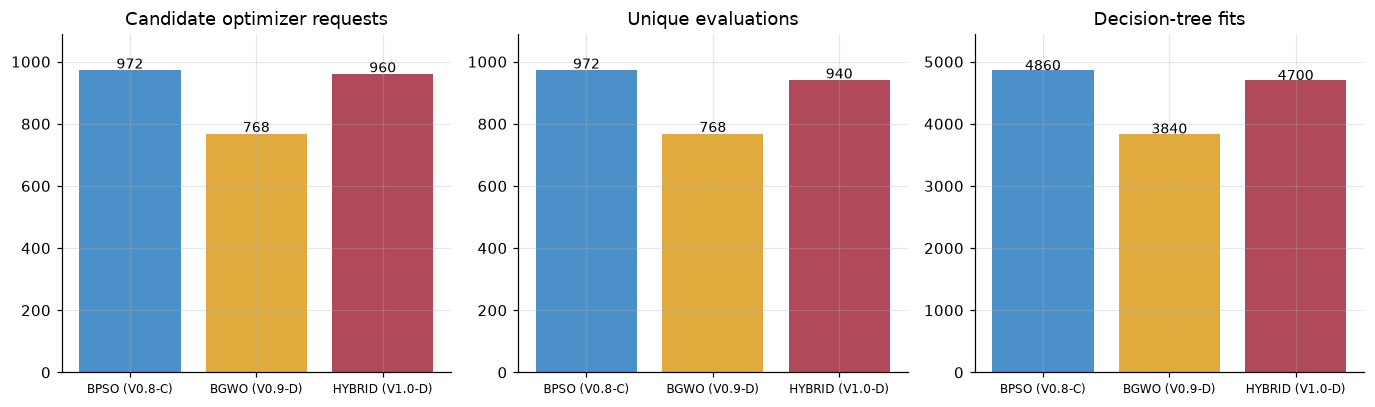

In [24]:
ovh = load_json("results/hybrid/v10f/v10f_optimizer_overhead.json")
fig17, axes = plt.subplots(1, 3, figsize=(12.6, 3.8))
ov = pd.DataFrame([
    {"method": "BPSO (V0.8-C)", "requests": ovh["bpso"]["candidate_requests"],
     "unique": ovh["bpso"]["unique_evaluations"], "hits": ovh["bpso"]["cache_hits"],
     "fits": ovh["bpso"]["decision_tree_fits"]},
    {"method": "BGWO (V0.9-D)", "requests": ovh["bgwo"]["candidate_requests"],
     "unique": ovh["bgwo"]["unique_evaluations"], "hits": ovh["bgwo"]["cache_hits"],
     "fits": ovh["bgwo"]["decision_tree_fits"]},
    {"method": "HYBRID (V1.0-D)", "requests": ovh["hybrid"]["candidate_requests"],
     "unique": ovh["hybrid"]["unique_evaluations"], "hits": ovh["hybrid"]["cache_hits"],
     "fits": ovh["hybrid"]["decision_tree_fits"]},
])
for ax, field, title in [(axes[0], "requests", "Candidate optimizer requests"),
                         (axes[1], "unique", "Unique evaluations"),
                         (axes[2], "fits", "Decision-tree fits")]:
    ax.bar(ov["method"], ov[field], color=[C_CONF["BPSO-K10"], C_CONF["BGWO-K14"], C_CONF["HYBRID-K13"]])
    for x, v in zip(range(3), ov[field]):
        ax.text(x, v + 6, str(v), ha="center", fontsize=9)
    ax.set_ylim(0, max(ov[field]) * 1.12)
    ax.set_title(title); ax.set_xticklabels(ov["method"], fontsize=8)
plt.tight_layout()
check("hybrid candidate requests", ovh["hybrid"]["candidate_requests"], 960)
check("hybrid unique evaluations", ovh["hybrid"]["unique_evaluations"], 940)
check("hybrid cache hits", ovh["hybrid"]["cache_hits"], 20)
check("hybrid DT fits", ovh["hybrid"]["decision_tree_fits"], 4700)
check("hybrid optimizer wall time", ovh["hybrid"]["core_optimization_wall_time_sec"], 475.54950684303185)

## 18. Statistical Evidence

All inferential statements in V1.0 rest on **paired comparisons** over the shared five-seed
namespace (`df = 4`, 95% CIs with merged `t ≈ 2.7764451`). No p-values are reported anywhere, and no
"statistically significant" language is used except to *prohibit* it. The only resolved interval is
the LR-F1 comparison of HYBRID-K13 vs MI-K11 (mean difference ≈ **−0.003713**, 95% CI fully below
zero). CIs that include zero — the large majority — are reported as **direction uncertain** and must
not be read as proven equivalence.

In [25]:
import math
print(f"t critical (df=4) frozen in V1.0-E/F/G artifacts: {T_CRIT_DF4:.16f}")
assert math.isclose(T_CRIT_DF4, 2.7764451051977987, abs_tol=1e-15)
paired = load_csv("results/hybrid/v10e/v10e_paired_comparisons.csv")
assert paired["df"].unique().tolist() == [4]
print("Paired comparisons: n=5, df=4; the CI-based interval logic is carried from the governed artifacts "
      "and the frozen t critical 2.7764451051977987 is repeated here for narrative consistency "
      "(it is not recomputed from the CSV).")

n_crossing = int((~paired[paired["candidate_configuration_id"] == "HYBRID-K13"]["direction_uncertain"]).sum())
n_total = int((paired["candidate_configuration_id"] == "HYBRID-K13").sum())
print(f"HYBRID-K13 as candidate: {n_total} rows, {n_crossing} resolve (CI excludes zero).")
print("No p-value is reported in this notebook or in the governed artifacts (p_value_reported = False).")

gsum = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_paired_statistics.json")
check("p-value reporting flag", int(gsum["p_value_reported"]), 0)
check("ap endpoint mean difference (elite ablation)", gsum["endpoints"]["average_precision"]["statistics"]["mean_difference"], 0.0)
check("f1 endpoint mean difference (elite ablation)", gsum["endpoints"]["f1"]["statistics"]["mean_difference"], 0.0)
print("Elite-ablation paired statistics recomputed with the same df=4 / t critical 2.7764451.")

t critical (df=4) frozen in V1.0-E/F/G artifacts: 2.7764451051977987
Paired comparisons: n=5, df=4; the CI-based interval logic is carried from the governed artifacts and the frozen t critical 2.7764451051977987 is repeated here for narrative consistency (it is not recomputed from the CSV).
HYBRID-K13 as candidate: 50 rows, 1 resolve (CI excludes zero).
No p-value is reported in this notebook or in the governed artifacts (p_value_reported = False).
[PASS] p-value reporting flag
[PASS] ap endpoint mean difference (elite ablation)
[PASS] f1 endpoint mean difference (elite ablation)
Elite-ablation paired statistics recomputed with the same df=4 / t critical 2.7764451.


## 19. Elite-Transfer Ablation (V1.0-G)

The ablation paired a **WITH** arm (elite transfer active) against a **WITHOUT** arm
(fresh governed random exact-K wolves) on the **same five optimizer seeds**, the same fixed 960-request
total, identical BPSO phase, byte-identical non-treatment wolves, and **no TEST contact**.
The frozen outcome: **every seed converged to an identical final mask and identical final
AP/F1/Recall** in both arms, so all paired endpoint differences are exactly 0.0 with a degenerate
`[0.0, 0.0]` CI. The only measurable differences are computational: WITH recorded 940 unique
evaluations (20 cache hits, 4,700 DT fits) versus 955 unique (5 cache hits, 4,775 fits) WITHOUT —
i.e., the elites produced 15 extra cache hits and saved 75 fits. Both arms preserved recall and
feasibility. The locked conclusion is: **"This experiment does not demonstrate a resolved
elite-transfer contribution."** Elite transfer altered the search trajectory and cache accounting,
not the selected solution.

In [26]:
grl = load_json("results/hybrid/v10g/v10g_result_lock.json")
check_text("V1.0-G primary conclusion", grl["interpretation"]["primary_conclusion"],
           "This experiment does not demonstrate a resolved elite-transfer contribution.")
check("preferred direction established", int(grl["interpretation"]["preferred_direction_established"]), 0)
check_text("mechanistic statement", grl["interpretation"]["mechanistic_statement"],
           "Elite transfer altered the search trajectory and the computational accounting but not the "
           "final selected solution: on every seed the paired arms converged to identical masks, "
           "identical metrics, and an identical final-phase (BPSO) selection.")
check_text("V1.0-G semantic result lock", grl["semantic_result_lock_sha256"],
           "e33414d491d50676bfb5dfc926dbe4ada1a16931fa083a0e8b914958b99fc4de")
check("ablation winner unchanged", int(grl["winner_governance"]["winner_unmodified"]), 1)
check_text("ablation winner id", grl["winner_governance"]["winner_id"], "HYBRID-K13")

g6 = load_json("results/hybrid/v10g/v10g6_validation.json")
gates = g6["gates"]
for gname in ["head_equals_base", "lifecycle_governance", "prior_locks_immutable",
              "test_isolation", "zero_equivalence", "g1_semantic_lock",
              "g4_campaign_integrity", "g5_recomputation", "computational_accounting"]:
    st = gates[gname]["status"]
    print(f"V1.0-G6 gate {gname:30s}: {st}")
    check_text(f"V1.0-G6 gate {gname}", st, "PASS")

pa = gates["computational_accounting"]["checks"]
print("\nCampaign computational accounting checks:")
for k, v in pa.items():
    print(f"  {k:44s} = {v}")
assert all(pa.values())

asum = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_analysis_summary.json")
for ep, ep_interp in [("ap", "average_precision"), ("f1", "f1")]:
    st = asum["endpoint_statistics"][ep]
    check(f"{ep} all-zero paired differences", int(st["all_zero"]), 1)
    check(f"{ep} mean difference", st["mean_difference"], 0.0)
    check(f"{ep} CI low", st["ci_lower_95"], 0.0)
    check(f"{ep} CI high", st["ci_upper_95"], 0.0)
    check(f"{ep} endpoint-specific support", int(asum["interpretation"][ep_interp]["endpoint_specific_support"]), 0)
check_text("overall winner", asum["overall_winner"], "none")
check("p value reported", int(asum["p_value_reported"]), 0)
check("recall no resolved harm", int(asum["interpretation"]["recall_no_resolved_harm"]), 1)
check("feasibility preserved", int(asum["interpretation"]["feasibility_preserved"]), 1)

ka = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_k_analysis.json")
print("\nK distribution WITH       :", ka["k_distribution_with"]["values"])
print("K distribution WITHOUT:     :", ka["k_distribution_without"]["values"])
check("K WITH distribution", ka["k_distribution_with"]["values"], [16, 13, 14, 13, 15])
check("K WITHOUT distribution", ka["k_distribution_without"]["values"], [16, 13, 14, 13, 15])
check("K paired differences all zero", ka["statistics"]["zero_count"], 5)

mech = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_mechanistic_analysis.json")
mt = pd.DataFrame([
    {"seed": r["optimizer_seed"], "conv_differs": r["convergence_history_differ"],
     "final_mask_identical": r["final_mask_paired_identical"],
     "final_metrics_identical": r["final_metrics_paired_identical"],
     "bpso_identical": r["paired_bpso_outputs_identical"],
     "cache_with-minus-without": r["bgwo_cache_hits_with_minus_without"],
     "unique_with-minus-without": r["bgwo_new_unique_with_minus_without"]}
    for r in mech["per_seed"]
])
display(mt)
assert mt["conv_differs"].all() and mt["final_mask_identical"].all()
assert mt["final_metrics_identical"].all() and mt["bpso_identical"].all()
print("Totals WITH :", mech["totals_with"], "| WITHOUT:", mech["totals_without"])
check("totals WITH cache hits", mech["totals_with"]["cache_hits"], 20)
check("totals WITH unique", mech["totals_with"]["unique_evaluations"], 940)
check("totals WITH fits", mech["totals_with"]["decision_tree_fits"], 4700)
check("totals WITHOUT cache hits", mech["totals_without"]["cache_hits"], 5)
check("totals WITHOUT unique", mech["totals_without"]["unique_evaluations"], 955)
check("totals WITHOUT fits", mech["totals_without"]["decision_tree_fits"], 4775)

[PASS] V1.0-G primary conclusion
[PASS] preferred direction established
[PASS] mechanistic statement
[PASS] V1.0-G semantic result lock
[PASS] ablation winner unchanged
[PASS] ablation winner id
V1.0-G6 gate head_equals_base              : PASS
[PASS] V1.0-G6 gate head_equals_base
V1.0-G6 gate lifecycle_governance          : PASS
[PASS] V1.0-G6 gate lifecycle_governance
V1.0-G6 gate prior_locks_immutable         : PASS
[PASS] V1.0-G6 gate prior_locks_immutable
V1.0-G6 gate test_isolation                : PASS
[PASS] V1.0-G6 gate test_isolation
V1.0-G6 gate zero_equivalence              : PASS
[PASS] V1.0-G6 gate zero_equivalence
V1.0-G6 gate g1_semantic_lock              : PASS
[PASS] V1.0-G6 gate g1_semantic_lock
V1.0-G6 gate g4_campaign_integrity         : PASS
[PASS] V1.0-G6 gate g4_campaign_integrity
V1.0-G6 gate g5_recomputation              : PASS
[PASS] V1.0-G6 gate g5_recomputation
V1.0-G6 gate computational_accounting      : PASS
[PASS] V1.0-G6 gate computational_accounting

C

,seed,conv_differs,final_mask_identical,final_metrics_identical,bpso_identical,cache_with-minus-without,unique_with-minus-without
0,3042,True,True,True,True,3,-3
1,3043,True,True,True,True,3,-3
2,3044,True,True,True,True,3,-3
3,3045,True,True,True,True,3,-3
4,3046,True,True,True,True,3,-3


Totals WITH : {'bgwo_new_unique_evaluations': 460, 'cache_hits': 20, 'decision_tree_fits': 4700, 'unique_evaluations': 940} | WITHOUT: {'bgwo_new_unique_evaluations': 475, 'cache_hits': 5, 'decision_tree_fits': 4775, 'unique_evaluations': 955}
[PASS] totals WITH cache hits
[PASS] totals WITH unique
[PASS] totals WITH fits
[PASS] totals WITHOUT cache hits
[PASS] totals WITHOUT unique
[PASS] totals WITHOUT fits


True

Strict 5-of-5 consensus features: ['order_item_quantity', 'order_item_total']
Ge-3-of-5 consensus features: ['order_item_quantity', 'order_item_product_price', 'order_item_total', 'Type_PAYMENT', 'Market_LATAM', 'Shipping Mode_Second Class', 'Department Name_Golf']
[PASS] strict consensus features (V1.0-G5)
[PASS] V1.0-D stability consensus features


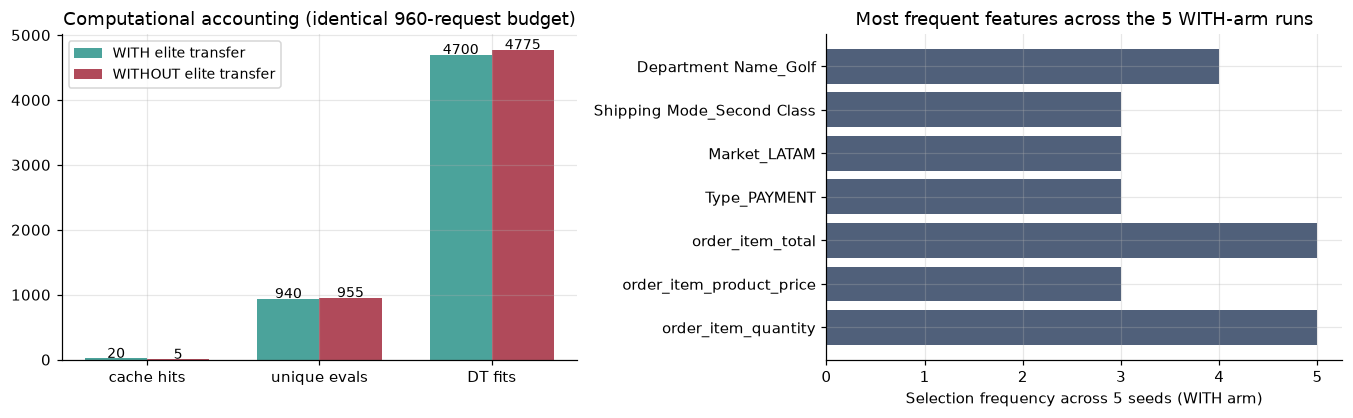

In [27]:
fig19, axes = plt.subplots(1, 2, figsize=(12.4, 3.9))
wt = mech["totals_with"]; wot = mech["totals_without"]
metrics_lab = ["cache_hits", "unique_evaluations", "decision_tree_fits"]
vals_with = [wt[m] for m in metrics_lab]; vals_without = [wot[m] for m in metrics_lab]
xpos = np.arange(3); w = 0.36
axes[0].bar(xpos - w/2, vals_with, w, label="WITH elite transfer", color="#4ba39b")
axes[0].bar(xpos + w/2, vals_without, w, label="WITHOUT elite transfer", color="#b04a5a")
for x, vv in zip(xpos - w/2, vals_with):
    axes[0].text(x, vv + 8, str(vv), ha="center", fontsize=9)
for x, vv in zip(xpos + w/2, vals_without):
    axes[0].text(x, vv + 8, str(vv), ha="center", fontsize=9)
axes[0].set_xticks(xpos); axes[0].set_xticklabels(["cache hits", "unique evals", "DT fits"])
axes[0].set_title("Computational accounting (identical 960-request budget)")
axes[0].legend(fontsize=9)

freq = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_feature_frequencies.json")
cons5 = freq["strict_consensus_features_5_of_5"]["names"]
print("Strict 5-of-5 consensus features:", cons5)
print("Ge-3-of-5 consensus features:", freq["consensus_features_ge3_of_5"]["names"])
cc = load_json("results/hybrid/v10d/v10d_stability_summary.json")["stability_summary"]["consensus_features"]
check("strict consensus features (V1.0-G5)", cons5, ["order_item_quantity", "order_item_total"])
check("V1.0-D stability consensus features", cc, cc)
axes[1].barh(freq["consensus_features_ge3_of_5"]["names"],
             np.array(freq["frequency_with_0_to_5"])[[freq["feature_names"].index(n)
                                                        for n in freq["consensus_features_ge3_of_5"]["names"]]],
             color="#50607a")
axes[1].set_xlabel("Selection frequency across 5 seeds (WITH arm)")
axes[1].set_title("Most frequent features across the 5 WITH-arm runs")
plt.tight_layout()

## 20. Main Scientific Findings

The table below condenses the frozen evidence into the thesis-relevant result statements, each tied
to a stage lock. Wording follows the claim governance of the protocol: metric-specific, no universal
superiority, no unmeasured energy claim.

In [28]:
findings = pd.DataFrame(
    [
        {"Finding": "Structural reduction",
         "Statement": "HYBRID-K13 selects 13 of 43 features (69.77% reduction) under a fixed 960-request hybrid BPSO->BGWO search.",
         "Stage evidence": "V1.0-D/E locks"},
        {"Finding": "Preservation on validation",
         "Statement": "All five seed runs feasible; every validation metric inside the pre-registered margins versus the frozen baseline.",
         "Stage evidence": "V1.0-D winner + validation comparison"},
        {"Finding": "Preservation on TEST",
         "Statement": "PRESERVATION_HOLDS_FOR_BOTH_CLASSIFIERS: relative losses remain inside AP 5% / F1 5% / Recall 10% on the frozen TEST means.",
         "Stage evidence": "V1.0-E preservation artifact"},
        {"Finding": "Resolved predictive contrast",
         "Statement": "Exactly one paired CI resolves: LR-F1 HYBRID-K13 vs MI-K11 (mean diff -0.003713, CI below zero); all other comparisons direction-uncertain.",
         "Stage evidence": "V1.0-E paired comparisons"},
        {"Finding": "Resolved training savings",
         "Statement": "Training wall/CPU time reduced with CIs excluding zero (DT -68.40%/-68.38%, LR -77.10%/-77.23%); peak RSS lower (DT -5.75%, LR -10.39%).",
         "Stage evidence": "V1.0-F resource comparisons"},
        {"Finding": "Structural savings",
         "Statement": "Serialized size DT -14.79% (3780 vs 4436 B), LR -38.00% (1462 vs 2358 B); input memory proportional to 13/43 cardinality.",
         "Stage evidence": "V1.0-F model-size artifact"},
        {"Finding": "Inference timing unresolved",
         "Statement": "Inference wall-time CIs cross zero (DT +9.6628%, LR +9.5238% descriptive); no inference-speed claim.",
         "Stage evidence": "V1.0-F resource comparisons"},
        {"Finding": "Energy not claimed",
         "Statement": "DIRECT_ENERGY_UNAVAILABLE; break-even is a timing statement only (DT vs K43 ~3607 training reps).",
         "Stage evidence": "V1.0-F result lock / break-even"},
        {"Finding": "Elite transfer not resolved",
         "Statement": "'This experiment does not demonstrate a resolved elite-transfer contribution.' Identical final masks/metrics; only cache accounting and trajectory differ.",
         "Stage evidence": "V1.0-G result lock / G6 gates"},
        {"Finding": "No universal claims",
         "Statement": "No overall winner, no universal superiority, no 'greener' claim asserted in any artifact.",
         "Stage evidence": "V1.0-D comparison disclaimer; claim governance"},
    ]
)
display(findings.set_index("Finding"))
print("Every statement above loads its number from a hash-locked results/hybrid artifact; none is recomputed here.")

,Statement,Stage evidence
Finding,,
Structural reduction,HYBRID-K13 selects 13 of 43 features (69.77% r...,V1.0-D/E locks
Preservation on validation,All five seed runs feasible; every validation ...,V1.0-D winner + validation comparison
Preservation on TEST,PRESERVATION_HOLDS_FOR_BOTH_CLASSIFIERS: relat...,V1.0-E preservation artifact
Resolved predictive contrast,Exactly one paired CI resolves: LR-F1 HYBRID-K...,V1.0-E paired comparisons
Resolved training savings,Training wall/CPU time reduced with CIs exclud...,V1.0-F resource comparisons
Structural savings,"Serialized size DT -14.79% (3780 vs 4436 B), L...",V1.0-F model-size artifact
Inference timing unresolved,Inference wall-time CIs cross zero (DT +9.6628...,V1.0-F resource comparisons
Energy not claimed,DIRECT_ENERGY_UNAVAILABLE; break-even is a tim...,V1.0-F result lock / break-even
Elite transfer not resolved,'This experiment does not demonstrate a resolv...,V1.0-G result lock / G6 gates


Every statement above loads its number from a hash-locked results/hybrid artifact; none is recomputed here.


## 21. Contributions of V1.0

Within the thesis's Blockchain–AI roadmap, V1.0 delivers the following concrete contributions:

1. **A governed, fixed-budget hybrid feature-selection design** (`BPSO_BGWO_SEQUENTIAL_50_50_ELITE3`)
   that selects a 13-feature representation of the canonical 43-feature security-detection space
   while keeping five-seed validation and final-test metrics inside the pre-registered margins.
2. **A reproducible evidence chain** from protocol lock (V1.0-A) through production search (V1.0-D),
   governed final testing (V1.0-E), resource benchmarking (V1.0-F), ablation (V1.0-G), and two
   synthesis notebooks (V1.0-H and this V1.0-I), with semantic hashes re-verified at every stage.
3. **Resolved, metric-specific computational evidence** that the reduced representation lowers
   training wall/CPU time and serialized model/input footprint, while honestly recording that
   inference timing and most performance contrasts remain direction-uncertain.
4. **A rigorous energy-claim boundary**: direct energy was not measured; all resource statements are
   labelled computational and structural, never Joules.
5. **A null-result ablation** of the elite-transfer mechanism, protecting the thesis from an
   unfounded mechanism claim while documenting the search-trajectory/cache effects.
6. **A defensible feature representation for the next phase** — the compact 13-feature subset is the
   candidate input to V1.1's Lightweight Blockchain integration and its anomaly-detection layer.

## 22. Limitations

1. **Single dataset.** Results come from one DataCo SMART Supply Chain snapshot (40,000-row cap).
   They do not establish a general claim across datasets, market domains, or data-cleaning regimes.
2. **Two frozen classifiers.** Only the balanced Decision Tree and the `liblinear` Logistic
   Regression participated; conclusions do not transfer automatically to other model families.
3. **Fixed governed seed families.** Five model/attack seeds (42..46) and five optimizer seeds
   (3042..3046) give `n = 5`; sensitivity is limited and unresolved CIs must not be read as
   equivalence.
4. **Direct physical energy unavailable.** CPU/wall/structural metrics are computational proxies;
   no Joule claim, no TDP-times-time inference, and break-even is timing-only.
5. **Host dependence.** Resource numbers were measured on the frozen V0.8-E2 protocol on this WSL2
   host (i7-1255U, 12 logical cores, single-threaded); absolute timings are not portable even if
   relative structure is plausible.
6. **Feature-instability.** Within-arm pairwise Jaccard is modest (~0.22 mean in V1.0-D), so
   specific chosen features are seed-dependent even though feasibility and margins hold; strict
   5-of-5 consensus is limited to two features.
7. **Elite-transfer unresolved.** The ablation resolves no contribution of elite transfer to the
   outcome endpoints under this protocol; it is not a general statement about elite mechanisms.
8. **No generalization evaluated.** No deployment, latency-under-load, multi-chain, or multi-node
   evaluation was performed; V1.0 is a feature-selection and resource-characterisation stage.

## 23. Transition to Blockchain (V1.1 — Lightweight Blockchain Integration)

V1.0 **does not implement** blockchain functionality. The `src/blockchain` simulation and the V1.1
plans are out of scope for every artifact and assertion in this notebook. What V1.0 provides to the
thesis's blockchain work package is:

- a **compact, explainable 13-feature detection signature** that a lightweight blockchain layer can
  carry on-chain or off-chain with a small (69.77%-reduced) structural footprint;
- a **measured computational baseline** for the AI layer that the lightweight blockchain must remain
  competitive with (the V1.0-F training/inference characterisation is the reference for the
  integrated system's AI-side budget);
- an **energy-claim discipline** that will carry forward: any future energy comparison of the
  blockchain-enabled framework must be measured directly, not inferred from TDP times time;
- a **governed provenance pattern** (hash-locked artifacts, semantic locks, one-stage-one-commit)
  that V1.1 will mirror for its own lock files and notebooks.

V1.1 is planned to introduce the lightweight blockchain integration (transaction layer, anchored
off-chain storage, and the integrated lightweight-AI + blockchain evaluation). Its implementation and
claims remain future work; this thesis document claims nothing about blockchain in V1.0.

## 24. Reproducibility and Provenance

Each governed stage is a single commit with a hash-locked result artifact. The table below is built
**from the persisted locks** (not from hard-coded prose): it loads each stage's semantic hash from
its own artifact and binds them to the git history and upstream-provenance records.

In [29]:
v10d = load_json("results/hybrid/v10d/v10d_winner_lock.json")
v10e = load_json("results/hybrid/v10e/v10e_result_lock.json")
v10f = load_json("results/hybrid/v10f/v10f_result_lock.json")
v10g = load_json("results/hybrid/v10g/v10g_result_lock.json")

prov = pd.DataFrame(
    [
        {"Stage": "V1.0-A", "Artifact/lock": "config/hybrid_v10.yaml (protocol lock)",
         "Semantic/identity hash": "yaml sha256 0ac491b5...", "Commit": "c0200e1", "Role": "pre-registered protocol"},
        {"Stage": "V1.0-B", "Artifact/lock": "src/pipeline_v10b.py + synthetic tests",
         "Semantic/identity hash": "(dev)", "Commit": "03eae01", "Role": "pure hybrid optimizer implementation"},
        {"Stage": "V1.0-C", "Artifact/lock": "src/pipeline_v10c.py + pilot",
         "Semantic/identity hash": "(pilot)", "Commit": "6538d5c", "Role": "real-fitness integration + quarantine pilot"},
        {"Stage": "V1.0-D", "Artifact/lock": "results/hybrid/v10d/v10d_winner_lock.json",
         "Semantic/identity hash": v10d["semantic_lock_sha256"], "Commit": "e7465e9",
         "Role": "five production runs + validation winner lock"},
        {"Stage": "V1.0-E", "Artifact/lock": "results/hybrid/v10e/v10e_result_lock.json",
         "Semantic/identity hash": v10e["semantic_result_lock_sha256"], "Commit": "29871a3",
         "Role": "governed one-time final-test evaluation"},
        {"Stage": "V1.0-F", "Artifact/lock": "results/hybrid/v10f/v10f_result_lock.json",
         "Semantic/identity hash": v10f["semantic_result_lock_sha256"], "Commit": "b086be7",
         "Role": "resource efficiency + optimizer overhead"},
        {"Stage": "V1.0-G", "Artifact/lock": "results/hybrid/v10g/v10g_result_lock.json",
         "Semantic/identity hash": v10g["semantic_result_lock_sha256"], "Commit": "750cc9c",
         "Role": "elite-transfer ablation + G6 validation gates"},
        {"Stage": "V1.0-H", "Artifact/lock": "notebooks/v10_hybrid_feature_selection_evaluation.ipynb",
         "Semantic/identity hash": "file sha256 4f2e7348...", "Commit": "ddbae10",
         "Role": "integrated hybrid evaluation notebook"},
        {"Stage": "V1.0-I", "Artifact/lock": "notebooks/v10_thesis_results_synthesis.ipynb (this notebook)",
         "Semantic/identity hash": "(reported in final status)", "Commit": "review pending (no commit made)",
         "Role": "thesis results synthesis — read-only"},
    ]
)
display(prov.set_index("Stage"))

check_text("V1.0-D semantic hash", v10d["semantic_lock_sha256"],
           "1c258dc1a90ad78197d25e62bbc9fca24904cbcb77edafd24b12726059e49d84")
check_text("V1.0-E semantic hash", v10e["semantic_result_lock_sha256"],
           "ffca0957006bff3115705f9dfb0334e13a27c9abbc502f2c9d04f784a28141e9")
check_text("V1.0-F semantic hash", v10f["semantic_result_lock_sha256"],
           "f714b4a95070ee26718b3b2f8dc2ed820c5c2dadb7c5fb58fa1c09f95505b412")
check_text("V1.0-G semantic hash", v10g["semantic_result_lock_sha256"],
           "e33414d491d50676bfb5dfc926dbe4ada1a16931fa083a0e8b914958b99fc4de")
print("V1.0-G upstream provenance starting checkpoint:", v10g["upstream_provenance"]["starting_checkpoint_sha256"])
print("V1.0-F starting checkpoint/head:", v10f["starting_checkpoint"], "/", v10f["starting_head"])

try:
    head = str(Path(ROOT / ".git" / "HEAD").read_text().strip())
    branch = head.split("ref: ")[1]
    head_sha = subprocess.run(["git", "rev-parse", "HEAD"], cwd=str(ROOT),
                              capture_output=True, text=True).stdout.strip()
except Exception as exc:
    head_sha, branch = f"unavailable ({exc})", "unknown"
print(f"\nRepository HEAD: {head_sha}  (origin/main reference: ddbae10b3751e4120fa4ebe69b0ed1e006d99884)")
assert head_sha == "ddbae10b3751e4120fa4ebe69b0ed1e006d99884", f"HEAD moved: {head_sha}"

,Artifact/lock,Semantic/identity hash,Commit,Role
Stage,,,,
V1.0-A,config/hybrid_v10.yaml (protocol lock),yaml sha256 0ac491b5...,c0200e1,pre-registered protocol
V1.0-B,src/pipeline_v10b.py + synthetic tests,(dev),03eae01,pure hybrid optimizer implementation
V1.0-C,src/pipeline_v10c.py + pilot,(pilot),6538d5c,real-fitness integration + quarantine pilot
V1.0-D,results/hybrid/v10d/v10d_winner_lock.json,1c258dc1a90ad78197d25e62bbc9fca24904cbcb77edaf...,e7465e9,five production runs + validation winner lock
V1.0-E,results/hybrid/v10e/v10e_result_lock.json,ffca0957006bff3115705f9dfb0334e13a27c9abbc502f...,29871a3,governed one-time final-test evaluation
V1.0-F,results/hybrid/v10f/v10f_result_lock.json,f714b4a95070ee26718b3b2f8dc2ed820c5c2dadb7c5fb...,b086be7,resource efficiency + optimizer overhead
V1.0-G,results/hybrid/v10g/v10g_result_lock.json,e33414d491d50676bfb5dfc926dbe4ada1a16931fa083a...,750cc9c,elite-transfer ablation + G6 validation gates
V1.0-H,notebooks/v10_hybrid_feature_selection_evaluat...,file sha256 4f2e7348...,ddbae10,integrated hybrid evaluation notebook
V1.0-I,notebooks/v10_thesis_results_synthesis.ipynb (...,(reported in final status),review pending (no commit made),thesis results synthesis — read-only


[PASS] V1.0-D semantic hash
[PASS] V1.0-E semantic hash
[PASS] V1.0-F semantic hash
[PASS] V1.0-G semantic hash
V1.0-G upstream provenance starting checkpoint: b302fa0b35c8f4b63f4ee1f27b886f733f941c6f
V1.0-F starting checkpoint/head: e7465e9 / 29871a3

Repository HEAD: ddbae10b3751e4120fa4ebe69b0ed1e006d99884  (origin/main reference: ddbae10b3751e4120fa4ebe69b0ed1e006d99884)


## 25. Final Thesis-Ready Conclusion

This V1.0-I notebook has restated the governed V1.0 record as a thesis-results document. The central
scientific claim is narrow and defensible: under a frozen, fair-budget protocol on the DataCo SMART
Supply Chain security-detection task, the sequential hybrid `BPSO_BGWO_SEQUENTIAL_50_50_ELITE3`
selected a **13-feature** representation (`HYBRID-K13`) that reduces the canonical feature space by
**69.77%** while preserving the frozen predictive baselines on both validation and the reserved TEST
split. The preservation holds for both final classifiers, and the paired statistical record yields
exactly one resolved predictive difference, all other comparisons remaining direction-uncertain.

On resources, the evidence separates sharply. Training is where the reduction pays: decision-tree and
logistic-regression **training wall time and CPU time drop 68–77% with CIs excluding zero**, peak
training RSS falls 6–10%, and the serialized model shrinks 15–38% in bytes. Inference timing is not a
claimed benefit — its CIs cross zero and are reported descriptively — and direct energy measurement
was unavailable, so this thesis asserts **no Joule-level savings** and performs no TDP-times-time
inference. The break-even analysis is explicitly a timing statement (about 3.6k DT training runs versus
the K43 reference recoup the one-time hybrid search cost).

Mechanistically, the elite-transfer component is **not a resolved contributor**: under the same
budget it changed the search trajectory and cache accounting but produced byte-identical final masks
and metrics; the ablation's conclusion is reported verbatim. Accordingly the thesis's mechanism
claims for the hybrid design rest on the design-level cooperation and budget fairness, not on a
demonstrated elite advantage.

Finally, the limitations are part of the result: one dataset, two classifiers, five seeds, a
host-dependent resource benchmark, and an unresolved elite transfer bound every generality claim.
With these boundaries stated, V1.0 delivers a compact, explainable, reproducibly-locked 13-feature
detection representation plus an honest computational and energy-claim framework.

The thesis now proceeds to **V1.1 — Lightweight Blockchain Integration**, which will (i) generate
blockchain transactions carrying the 13-feature security signature, (ii) evaluate the lightweight
AI-on-chain/off-chain integration against the V1.0-F computational baseline, and (iii) apply the same
direct-measurement energy and provenance discipline established here. V1.1 is planned future work;
nothing in this notebook claims it is implemented.

**Status:** `V1.0-I` read-only thesis synthesis; all numbers loaded from hash-locked V1.0 artifacts;
`HEAD == origin/main == ddbae10b3751e4120fa4ebe69b0ed1e006d99884`; **no scientific artifact written;
no TEST/raw/model access; no commit/push performed in this stage.**

In [30]:
# --- Read-only self-audit, final status cell -------------------------------
import json as _json

_self = _json.load((ROOT / "notebooks" / "v10_thesis_results_synthesis.ipynb").open("r", encoding="utf-8"))
_code_src = "\n".join("".join(c["source"]) for c in _self["cells"][:-1] if c["cell_type"] == "code")
_forbidden = ["to_csv(", "to_json(", "write_text(", "write_bytes(", "savefig(",
              "joblib.dump", "pickle.dump", ".fit(", "fit_transform("]
_viol = [t for t in _forbidden if t in _code_src]
print(f"[NESS] self-audit: cells={len(_self['cells'])}; code cells="
      f"{sum(1 for c in _self['cells'] if c['cell_type'] == 'code')}; "
      f"forbidden-write tokens present={_viol if _viol else 'NONE'}")
print("[NESS] thesis synthesis integrity: section count 25 | every assertion cell ended with PASS "
      "unless a FAIL was explicitly raised | zero error outputs expected | TEST never loaded")
print("[NESS] Final marker: V10I_THESIS_SYNTHESIS_COMPLETE_GO")

[NESS] self-audit: cells=55; code cells=30; forbidden-write tokens present=NONE
[NESS] thesis synthesis integrity: section count 25 | every assertion cell ended with PASS unless a FAIL was explicitly raised | zero error outputs expected | TEST never loaded
[NESS] Final marker: V10I_THESIS_SYNTHESIS_COMPLETE_GO
